In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sb

from sklearn.metrics import accuracy_score

from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve, roc_auc_score

from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import RobustScaler

import shap


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
Train_90_path = "../Data/Train_test/train_90.csv"

Train_120_path = "../Data/Train_test/train_120.csv"

Train_150_path = "../Data/Train_test/train_150.csv"


# test


Test_90_path = "../Data/Train_test/test_90.csv"

Test_120_path = "../Data/Train_test/test_120.csv"

Test_150_path = "../Data/churn_test_dataset_150.csv"

In [3]:
# Load the data

Data_train_90_df = pd.read_csv(Train_90_path)

Data_train_120_df = pd.read_csv(Train_120_path) 

Data_train_150_df = pd.read_csv(Train_150_path) 

Data_test_90_df = pd.read_csv(Test_90_path) 

Data_test_120_df = pd.read_csv(Test_120_path) 

Data_test_150_df = pd.read_csv(Test_150_path)  

-------
-------

## 90 days train_test dataset

In [4]:
# Income
HIGH_INCOME = ["SP", "RJ", "AM", "SE"]
MID_INCOME = ["PI", "PB", "MS", "ES", "BA", "AL", "PE", "RN", "CE"]
LOW_INCOME = ["RR", "RO", "MT", "GO", "TO", "RS", "SC", "PR", "MA", "MG", "AC", "PA", "AP", "DF"]

prov_income_map = {
    **{i:"high" for i in HIGH_INCOME},
    **{i:"mid" for i in MID_INCOME},
    **{i:"low" for i in LOW_INCOME}
}
prov_income_map

{'SP': 'high',
 'RJ': 'high',
 'AM': 'high',
 'SE': 'high',
 'PI': 'mid',
 'PB': 'mid',
 'MS': 'mid',
 'ES': 'mid',
 'BA': 'mid',
 'AL': 'mid',
 'PE': 'mid',
 'RN': 'mid',
 'CE': 'mid',
 'RR': 'low',
 'RO': 'low',
 'MT': 'low',
 'GO': 'low',
 'TO': 'low',
 'RS': 'low',
 'SC': 'low',
 'PR': 'low',
 'MA': 'low',
 'MG': 'low',
 'AC': 'low',
 'PA': 'low',
 'AP': 'low',
 'DF': 'low'}

In [5]:
# Generate binary columns from customer_state to distinguish the customer order state. We want to see if their state holds a high, medium, or low average income.

Data_train_90_df["state_income_level"] = Data_train_90_df.customer_state.map(prov_income_map)

Data_train_90_df["state_income_level_high"] = (Data_train_90_df["state_income_level"] == "high").astype(int)
Data_train_90_df["state_income_level_mid"] = (Data_train_90_df["state_income_level"] == "mid").astype(int)
Data_train_90_df["state_income_level_low"] = (Data_train_90_df["state_income_level"] == "low").astype(int)

Data_train_90_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,delivered,1.0,credit_card,1.0,entertainment,0,high,1,0,0
1,01f156677184504063bd19739f924af1,739.98,0.060569,784.80,-46.0,5.0,0.002873,2.0,gravatal,SC,delivered,1.0,credit_card,10.0,household,0,low,0,0,1
2,0313291a6f4f16df04dcf819d88c38ef,95.00,0.187158,112.78,0.0,1.0,0.017780,1.0,sao sebastiao,SP,processing,1.0,boleto,1.0,household,0,high,1,0,0
3,0636d30c77f0f9cfad81f1c9b58c791f,949.99,0.023127,971.96,-44.0,4.0,0.004674,2.0,itaquaquecetuba,SP,delivered,1.0,credit_card,10.0,entertainment,0,high,1,0,0
4,0659f2d6cabae94afd4d009c6d0e07dc,390.00,0.177282,918.28,0.0,1.0,0.003582,1.0,cacequi,RS,canceled,1.0,credit_card,4.0,automotive,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,ffe3e199b9d0b7fb7d2d29a5b9498447,146.90,0.103472,162.10,0.0,1.0,0.043429,2.0,uberlandia,MG,delivered,1.0,boleto,1.0,construction,0,low,0,0,1
8658,ffe4c3aa14d4702fb11fe5b3c4dd755c,118.90,0.154752,137.30,-15.0,5.0,0.013143,4.0,sarzedo,MG,delivered,1.0,credit_card,1.0,beauty,0,low,0,0,1
8659,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
8660,ffef0ffa736c7b3d9af741611089729b,109.90,0.265423,139.07,-22.0,5.0,0.025678,1.0,nova venecia,ES,delivered,1.0,credit_card,1.0,sports_leisure,0,mid,0,1,0


In [6]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

In [7]:
# Create one hot encoding for categorical features. Include drop = first to avoid multicollinearity

target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop="first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_90_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [8]:
# fit and transform the dataset

encoded_array = col_trans.transform(Data_train_90_df)

In [9]:
feature_names = col_trans.get_feature_names_out(Data_train_90_df.columns)
encoded_90_df = pd.DataFrame(encoded_array, columns= feature_names)

encoded_90_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__product_photos_qty,remainder__customer_city,remainder__customer_state,remainder__payment_sequential,remainder__payment_installments,remainder__churn_90,remainder__state_income_level,remainder__state_income_level_high,remainder__state_income_level_mid,remainder__state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,sarzedo,MG,1.0,1.0,0,low,0,0,1
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0


In [10]:
encoded_90_df.columns = encoded_90_df.columns.str.replace('remainder__', '')

encoded_90_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,product_photos_qty,customer_city,customer_state,payment_sequential,payment_installments,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,sarzedo,MG,1.0,1.0,0,low,0,0,1
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0


beyond one tear= the payment takes more than one year

-----

# Test dataset

In [11]:
Data_test_90_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
1,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0
2,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0
3,0014a5a58da615f7b01a4f5e194bf5ea,88.00,0.134318,99.82,-7.0,5.0,0.021491,2.0,sao paulo,SP,delivered,1.0,credit_card,3.0,beauty,0
4,00196fdb2bf9edfc35e88ebfbcf8d781,12.90,1.093023,27.00,1.0,3.0,0.080571,1.0,canoas,RS,delivered,1.0,credit_card,1.0,electronics,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39545,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0
39546,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,0.174222,3.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0
39547,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0
39548,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0


In [12]:
Data_test_90_df["state_income_level"] = Data_test_90_df.customer_state.map(prov_income_map)

Data_test_90_df["state_income_level_high"] = (Data_test_90_df["state_income_level"] == "high").astype(int)
Data_test_90_df["state_income_level_mid"] = (Data_test_90_df["state_income_level"] == "mid").astype(int)
Data_test_90_df["state_income_level_low"] = (Data_test_90_df["state_income_level"] == "low").astype(int)

Data_test_90_df 

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
1,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0,low,0,0,1
2,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0,high,1,0,0
3,0014a5a58da615f7b01a4f5e194bf5ea,88.00,0.134318,99.82,-7.0,5.0,0.021491,2.0,sao paulo,SP,delivered,1.0,credit_card,3.0,beauty,0,high,1,0,0
4,00196fdb2bf9edfc35e88ebfbcf8d781,12.90,1.093023,27.00,1.0,3.0,0.080571,1.0,canoas,RS,delivered,1.0,credit_card,1.0,electronics,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39545,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0,high,1,0,0
39546,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,0.174222,3.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0,low,0,0,1
39547,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0,high,1,0,0
39548,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0,high,1,0,0


In [13]:
Data_test_90_df["order_status"].value_counts()

order_status
delivered     38739
shipped         464
canceled        160
invoiced         95
processing       92
Name: count, dtype: int64

In [14]:
target_features = ["order_status", "payment_type", "product_cat"]



In [15]:
encoded_array_test = col_trans.transform(Data_test_90_df)

In [16]:
Data_test_90_df.columns

Index(['customer_unique_id', 'price', 'freight_to_price_ratio',
       'payment_value', 'dates_diff', 'review_score',
       'freight_to_weight_ratio', 'product_photos_qty', 'customer_city',
       'customer_state', 'order_status', 'payment_sequential', 'payment_type',
       'payment_installments', 'product_cat', 'churn_90', 'state_income_level',
       'state_income_level_high', 'state_income_level_mid',
       'state_income_level_low'],
      dtype='str')

In [17]:
Data_test_90_df.columns

Index(['customer_unique_id', 'price', 'freight_to_price_ratio',
       'payment_value', 'dates_diff', 'review_score',
       'freight_to_weight_ratio', 'product_photos_qty', 'customer_city',
       'customer_state', 'order_status', 'payment_sequential', 'payment_type',
       'payment_installments', 'product_cat', 'churn_90', 'state_income_level',
       'state_income_level_high', 'state_income_level_mid',
       'state_income_level_low'],
      dtype='str')

In [18]:
encoded_90_test_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_test_90_df.columns))

encoded_90_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__product_photos_qty,remainder__customer_city,remainder__customer_state,remainder__payment_sequential,remainder__payment_installments,remainder__churn_90,remainder__state_income_level,remainder__state_income_level_high,remainder__state_income_level_mid,remainder__state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,sarzedo,MG,1.0,1.0,0,low,0,0,1
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0


In [19]:
encoded_90_test_df.columns = encoded_90_test_df.columns.str.replace('remainder__', '')

encoded_90_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,product_photos_qty,customer_city,customer_state,payment_sequential,payment_installments,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,sarzedo,MG,1.0,1.0,0,low,0,0,1
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0


In [20]:
target_col = 'churn_90'

encoded_90_test_df[target_col] = encoded_90_test_df[target_col].astype(int)


for col in encoded_90_test_df.columns:
    if col != target_col:

        encoded_90_test_df[col] = pd.to_numeric(encoded_90_test_df[col], errors='coerce')


corr_matrix = encoded_90_test_df.corr(numeric_only=True)

churn_relationships = corr_matrix[target_col].drop(target_col)


feature_relation_table = pd.DataFrame({
    'Feature_Name': churn_relationships.index,
    'Correlation_Value': churn_relationships.values,
    'Absolute_Correlation': churn_relationships.abs().values})

In [21]:
feature_relation_table.to_excel("feature_churn_corr_table_90.xlsx")

--------

In [22]:
encoded_90_df["customer_unique_id"]

0       0032c76b20340da25249092a268ce66c
1       01f156677184504063bd19739f924af1
2       0313291a6f4f16df04dcf819d88c38ef
3       0636d30c77f0f9cfad81f1c9b58c791f
4       0659f2d6cabae94afd4d009c6d0e07dc
                      ...               
8657    ffe3e199b9d0b7fb7d2d29a5b9498447
8658    ffe4c3aa14d4702fb11fe5b3c4dd755c
8659    ffedff0547d809c90c05c2691c51f9b7
8660    ffef0ffa736c7b3d9af741611089729b
8661    ffffd2657e2aad2907e67c3e9daecbeb
Name: customer_unique_id, Length: 8662, dtype: str

# Train test split

In [23]:
X_train = encoded_90_df.drop(columns = ['churn_90', "customer_unique_id", "customer_city", "customer_state", "state_income_level"])

y_train = encoded_90_df['churn_90'].fillna(0).astype(int)

In [24]:
X_valtest = encoded_90_test_df.drop(columns = ['churn_90', "customer_unique_id", "customer_city", "customer_state", "state_income_level"])

y_valtest = encoded_90_test_df['churn_90'].fillna(0).astype(int)

In [25]:
encoded_90_df.dtypes.value_counts()

object    37
str        4
Name: count, dtype: int64

In [26]:
X_train = X_train.astype(int)


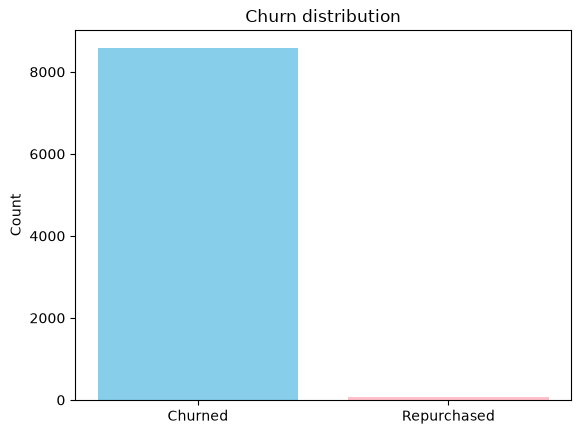

In [27]:
# Here. we see how much imbalance we have for out target feature
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [28]:
y_train

0       0
1       0
2       0
3       0
4       0
       ..
8657    0
8658    0
8659    0
8660    0
8661    0
Name: churn_90, Length: 8662, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, test_size= 0.5, random_state = 42)
X_val = X_val.astype(int)
X_test = X_test.astype(int)

In [30]:
print(X_train.shape)
print(X_valtest.shape)

(8662, 36)
(8662, 36)


In [31]:
# Here we group parameters for each supervised classification model that will be used
my_experiment_list = [
    {
        "name":"DT - gini",
        "clf":DecisionTreeClassifier,
        "params": {
            "criterion": "gini",
            "max_depth": 10,
            "random_state": 42
        }
    },
    {
        "name":"DT - entropy",
        "clf":DecisionTreeClassifier,
        "params": {
            "criterion": "entropy",
            "max_depth": 10,
            "random_state": 42
        }
    },
    {
        "name":"RF - gini_50",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "gini",
            "n_estimators": 50,
            "max_depth": 10,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"RF - gini_100",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "gini",
            "n_estimators": 100,
            "max_depth": 10,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"RF - gini_150",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "entropy",
            "n_estimators": 150,
            "max_depth": 10,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"LogReg",
        "clf":lambda **params: make_pipeline(RobustScaler(), LogisticRegression(**params)),
        "params": {
            "random_state": 42,
            "penalty": "l2",
            "C": 1.0
        }
    },
    {
        "name":"XGBoost - 100",
        "clf":XGBClassifier,
        "params": {
            'objective':'binary:logistic',
            'max_depth': 100,
            'alpha': 10,
            'learning_rate': 1.0,
            'n_estimators':100
        }
    },
]

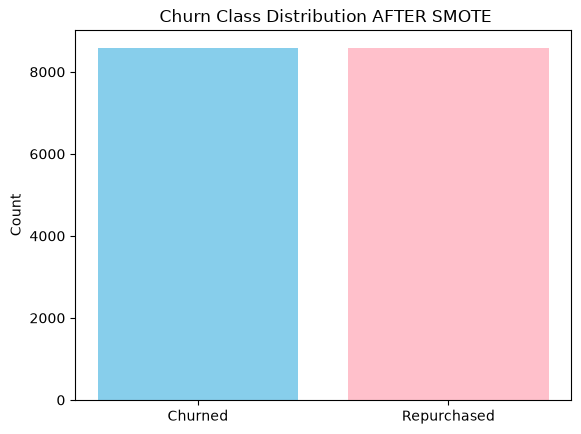

In [32]:
from imblearn.over_sampling import SMOTE

# We used SMOTE(Synthetic minority oversampling teachnique) to deal with imbalance by plotting artificial points for the minority class

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

-----

In [33]:
# This function draws a roc-auc curve to assess overfitting and model performance

def plot_auc(y_test, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

    # 3. Calculate AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # 4. Plot the ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')

    # Formatting details
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    return auc_score

------------------------------------
DT - gini
------------------------------------


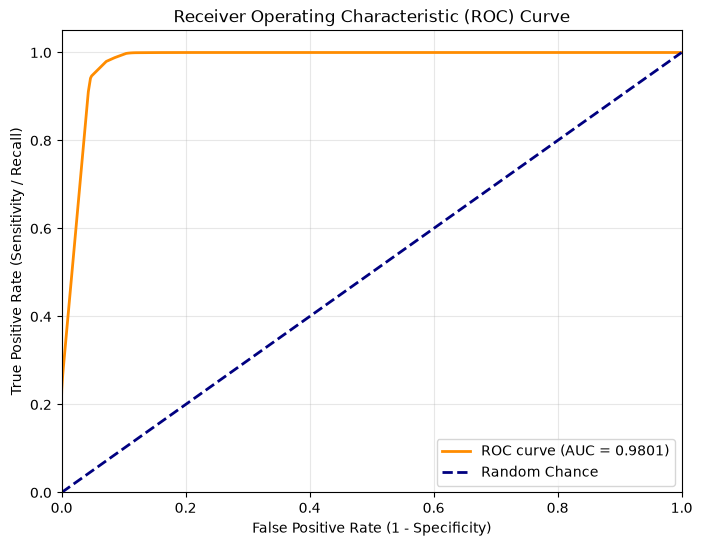

-----  Trainsm  -----
Model F1 score: 0.9550
Model accuracy: 0.9538
[[7963  620]
 [ 173 8410]]



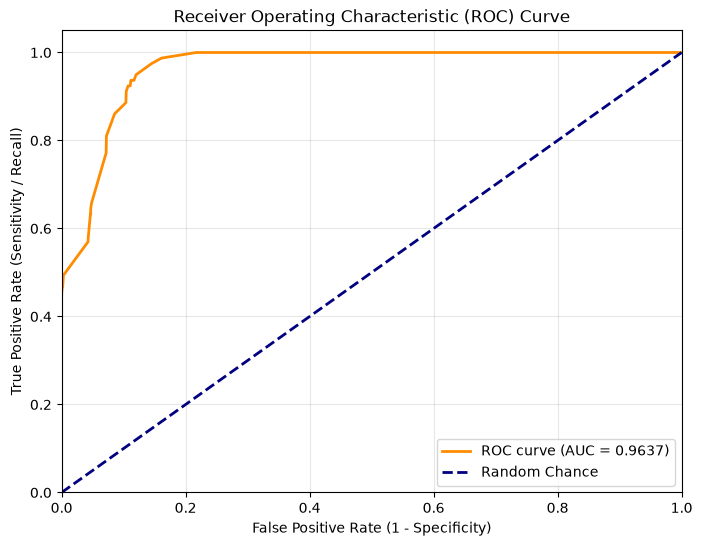

-----  Train  -----
Model F1 score: 0.1678
Model accuracy: 0.9267
[[7963  620]
 [  15   64]]



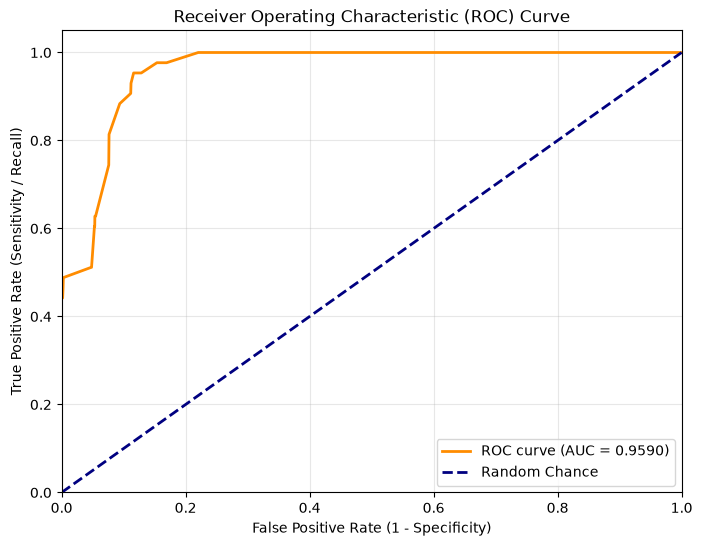

-----  Val  -----
Model F1 score: 0.1724
Model accuracy: 0.9224
[[3960  328]
 [   8   35]]



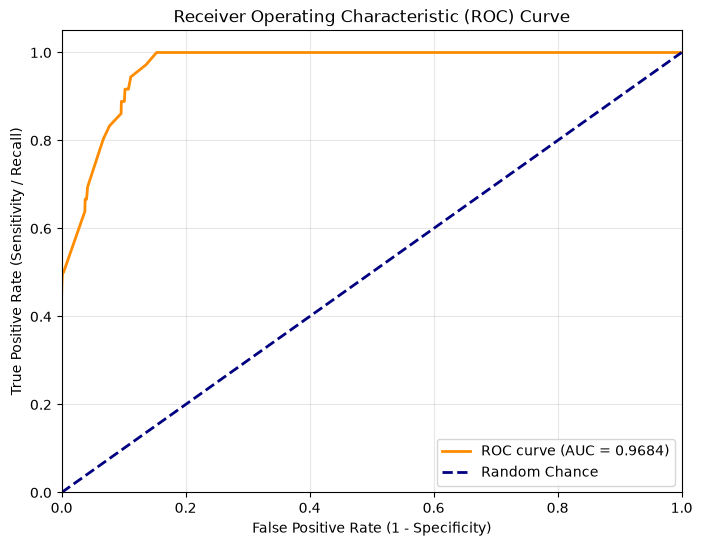

-----  Test  -----
Model F1 score: 0.1625
Model accuracy: 0.9310
[[4003  292]
 [   7   29]]

------------------------------------


------------------------------------
DT - entropy
------------------------------------


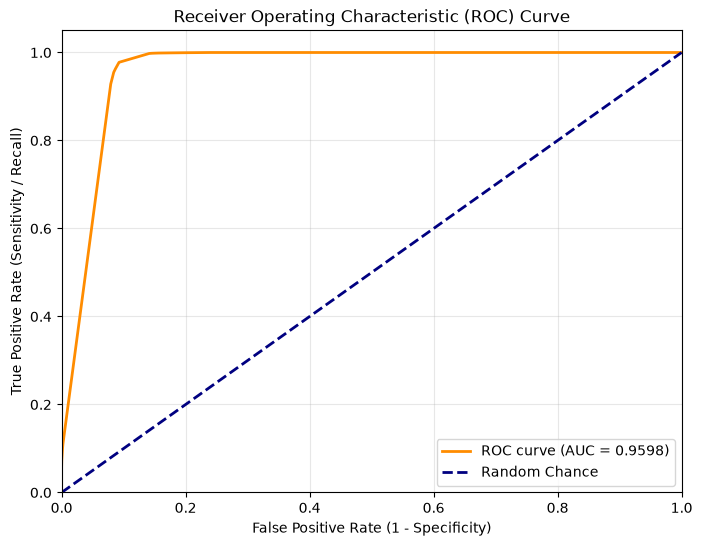

-----  Trainsm  -----
Model F1 score: 0.9444
Model accuracy: 0.9424
[[7784  799]
 [ 190 8393]]



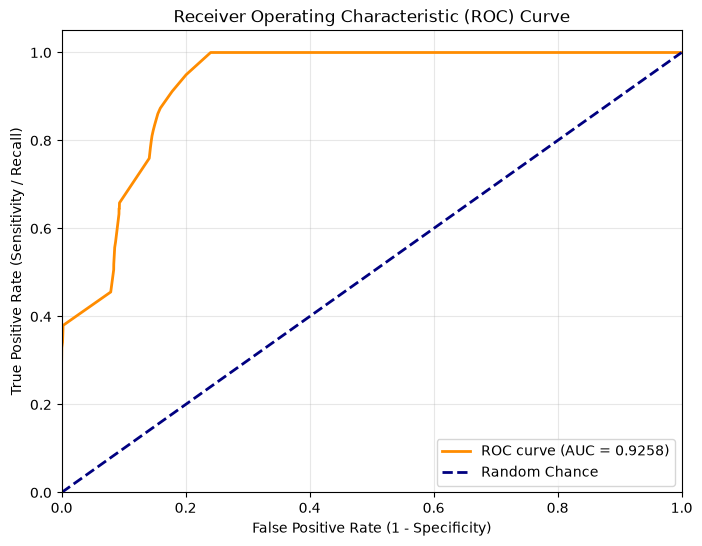

-----  Train  -----
Model F1 score: 0.1098
Model accuracy: 0.9045
[[7784  799]
 [  28   51]]



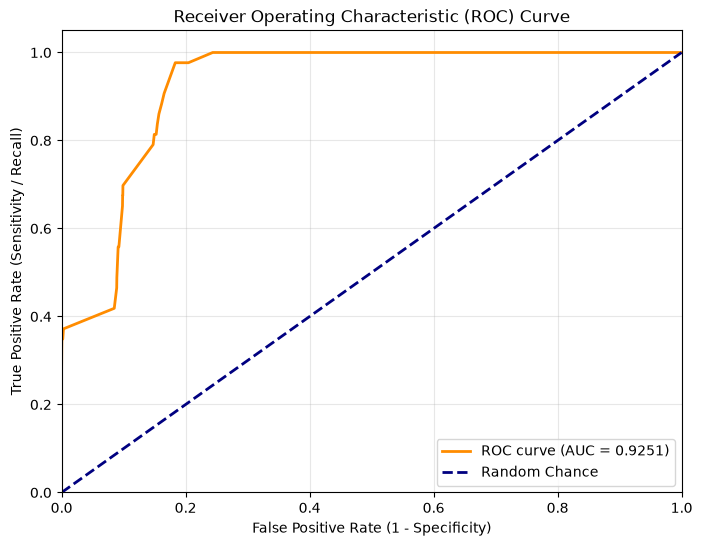

-----  Val  -----
Model F1 score: 0.1172
Model accuracy: 0.8991
[[3865  423]
 [  14   29]]



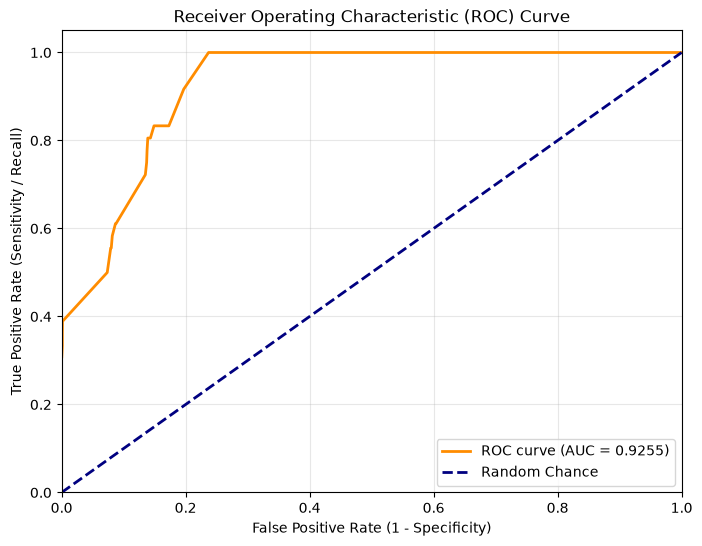

-----  Test  -----
Model F1 score: 0.1014
Model accuracy: 0.9100
[[3919  376]
 [  14   22]]

------------------------------------


------------------------------------
RF - gini_50
------------------------------------


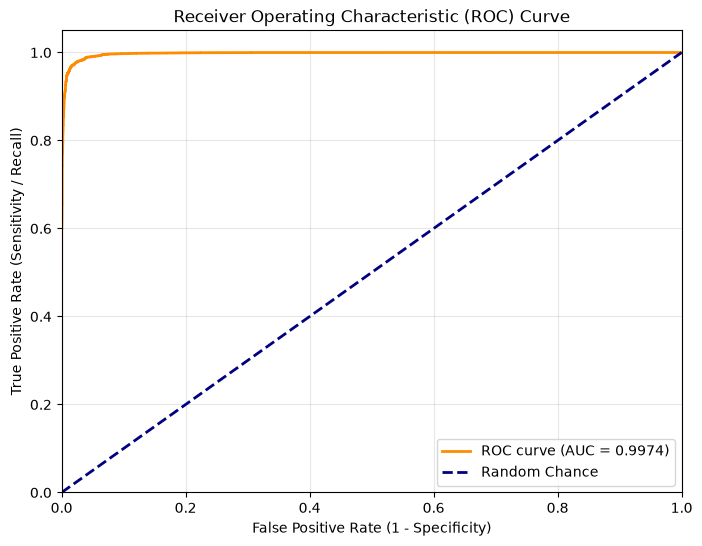

-----  Trainsm  -----
Model F1 score: 0.9548
Model accuracy: 0.9528
[[7795  788]
 [  23 8560]]



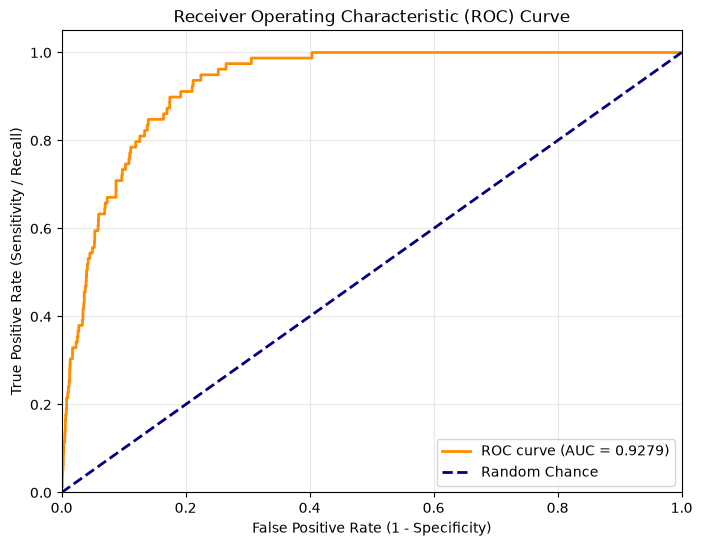

-----  Train  -----
Model F1 score: 0.1213
Model accuracy: 0.9064
[[7795  788]
 [  23   56]]



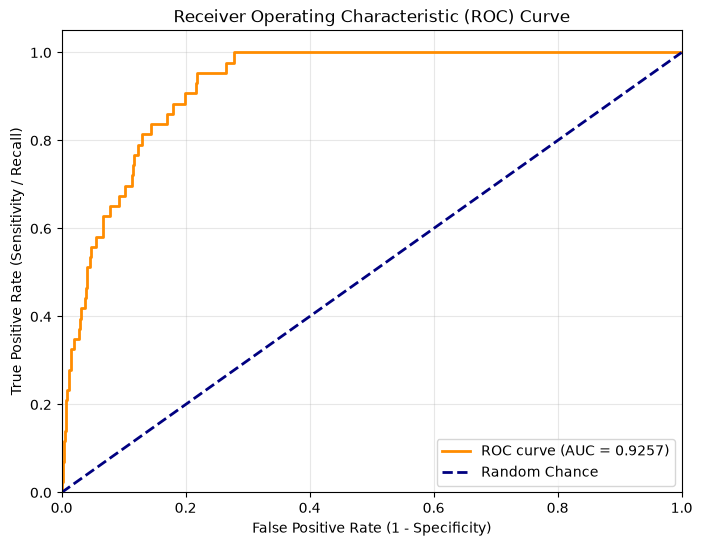

-----  Val  -----
Model F1 score: 0.1191
Model accuracy: 0.9009
[[3873  415]
 [  14   29]]



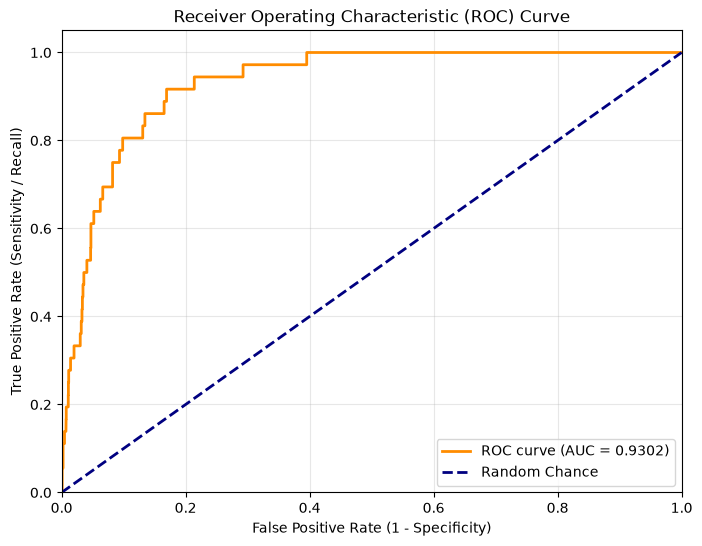

-----  Test  -----
Model F1 score: 0.1239
Model accuracy: 0.9118
[[3922  373]
 [   9   27]]

------------------------------------


------------------------------------
RF - gini_100
------------------------------------


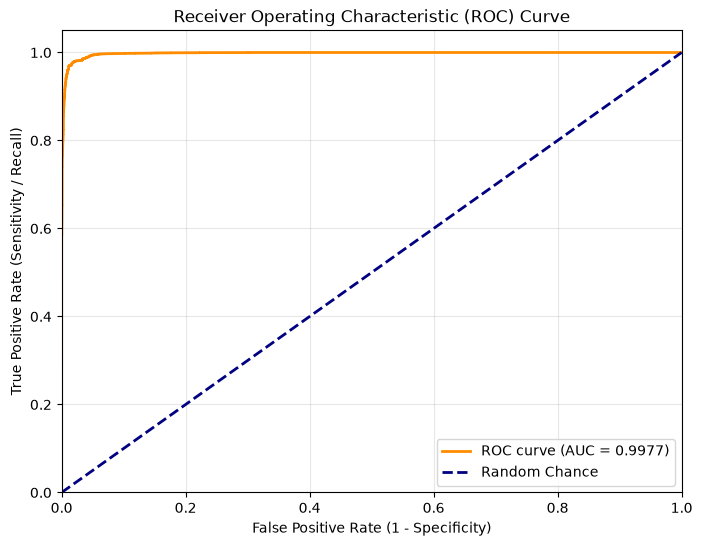

-----  Trainsm  -----
Model F1 score: 0.9602
Model accuracy: 0.9586
[[7895  688]
 [  22 8561]]



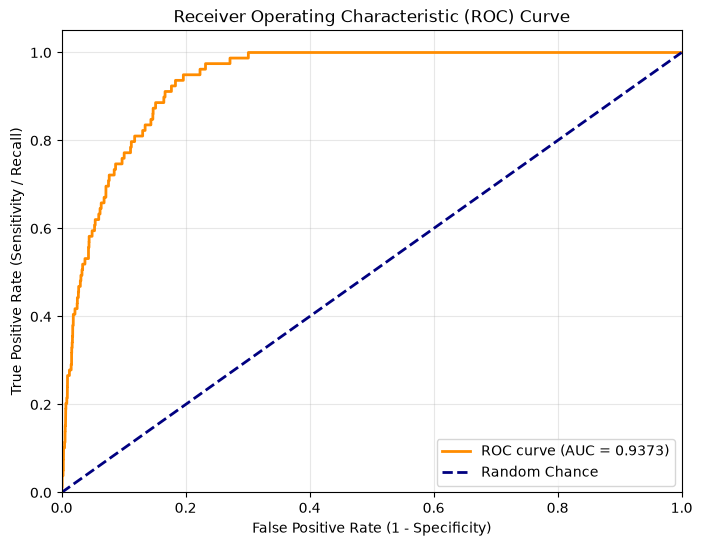

-----  Train  -----
Model F1 score: 0.1383
Model accuracy: 0.9180
[[7895  688]
 [  22   57]]



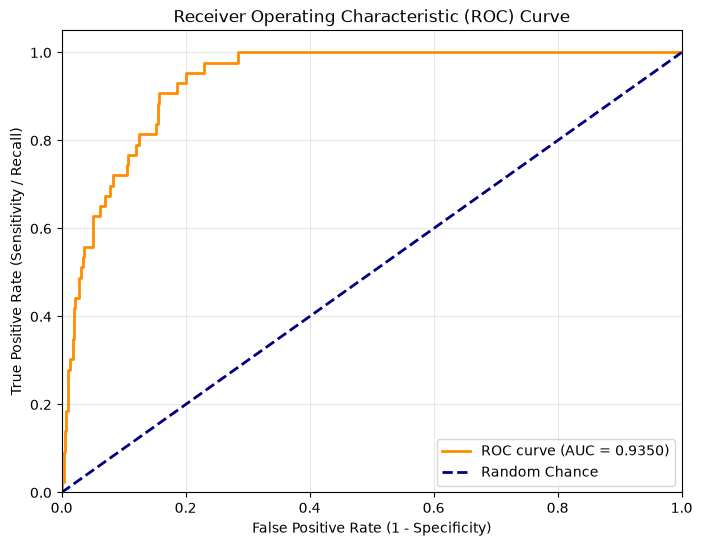

-----  Val  -----
Model F1 score: 0.1406
Model accuracy: 0.9125
[[3921  367]
 [  12   31]]



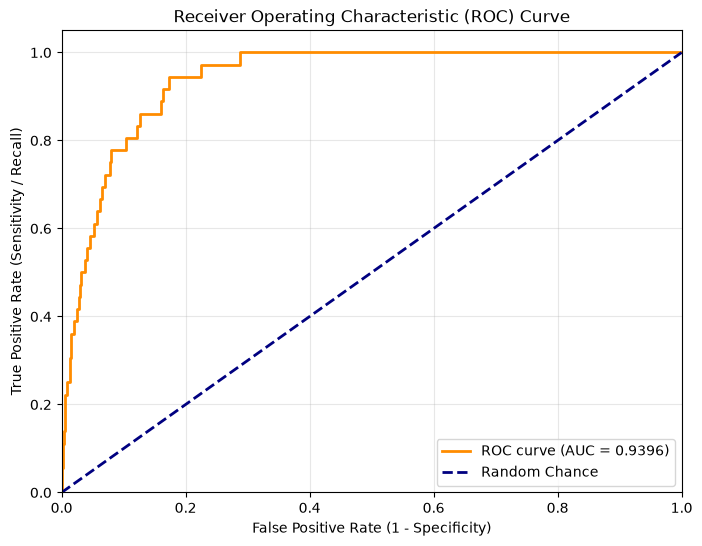

-----  Test  -----
Model F1 score: 0.1358
Model accuracy: 0.9236
[[3974  321]
 [  10   26]]

------------------------------------


------------------------------------
RF - gini_150
------------------------------------


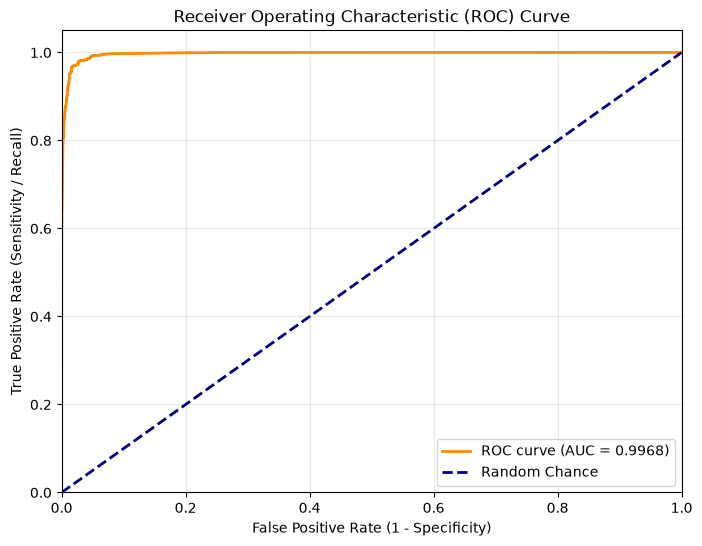

-----  Trainsm  -----
Model F1 score: 0.9562
Model accuracy: 0.9543
[[7823  760]
 [  24 8559]]



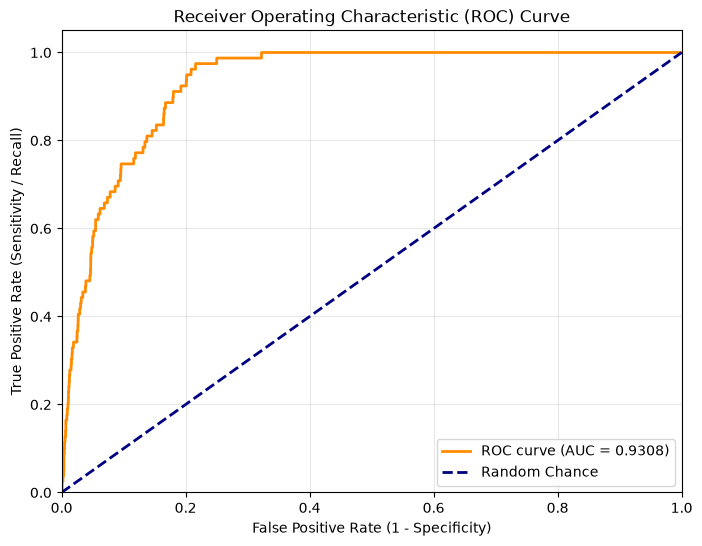

-----  Train  -----
Model F1 score: 0.1230
Model accuracy: 0.9095
[[7823  760]
 [  24   55]]



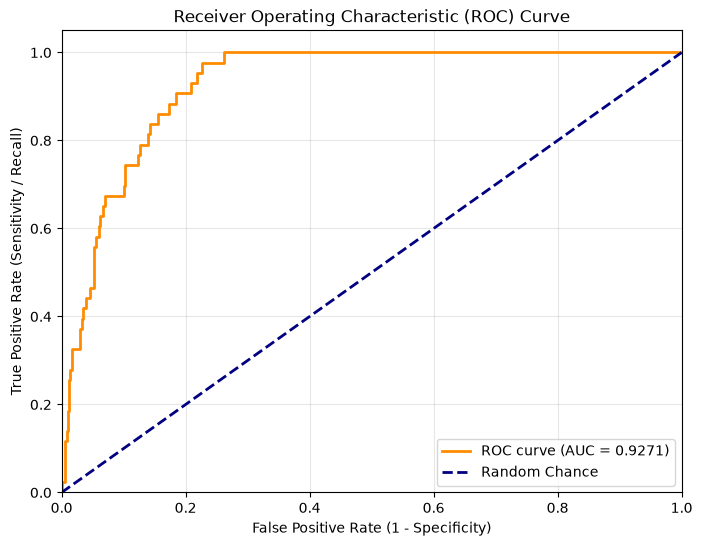

-----  Val  -----
Model F1 score: 0.1198
Model accuracy: 0.9016
[[3876  412]
 [  14   29]]



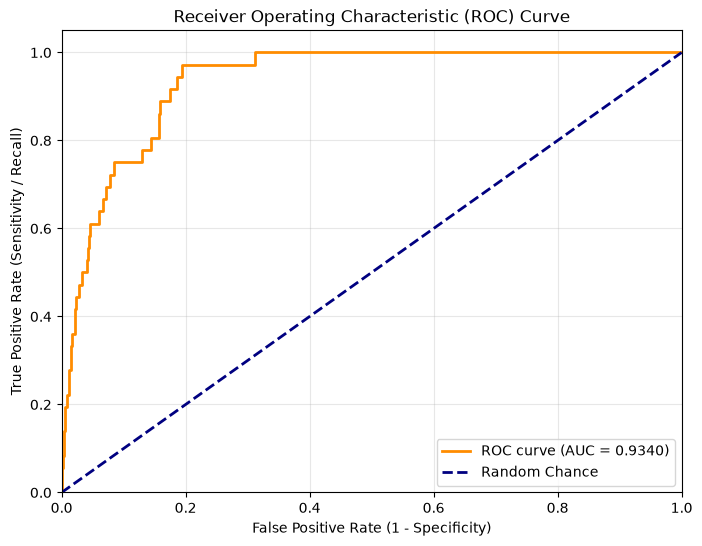

c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
Background dataset has 17166 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=17166 when initializing the masker.


-----  Test  -----
Model F1 score: 0.1268
Model accuracy: 0.9173
[[3947  348]
 [  10   26]]

------------------------------------


------------------------------------
LogReg
------------------------------------


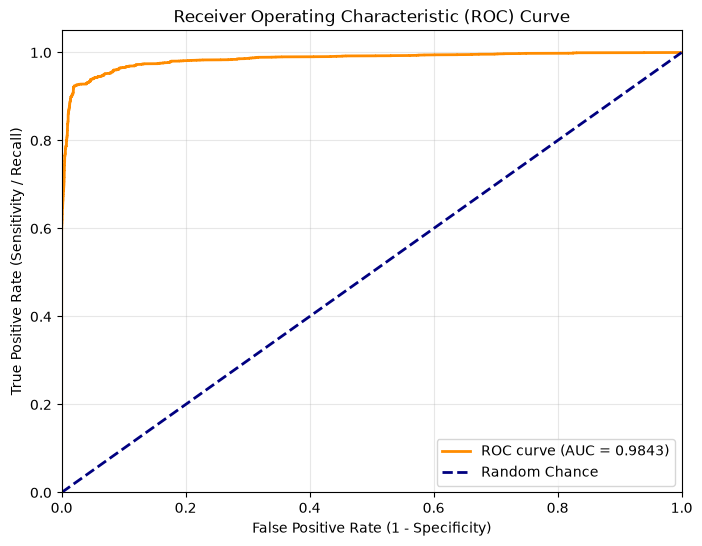

-----  Trainsm  -----
Model F1 score: 0.9471
Model accuracy: 0.9482
[[8308  275]
 [ 615 7968]]



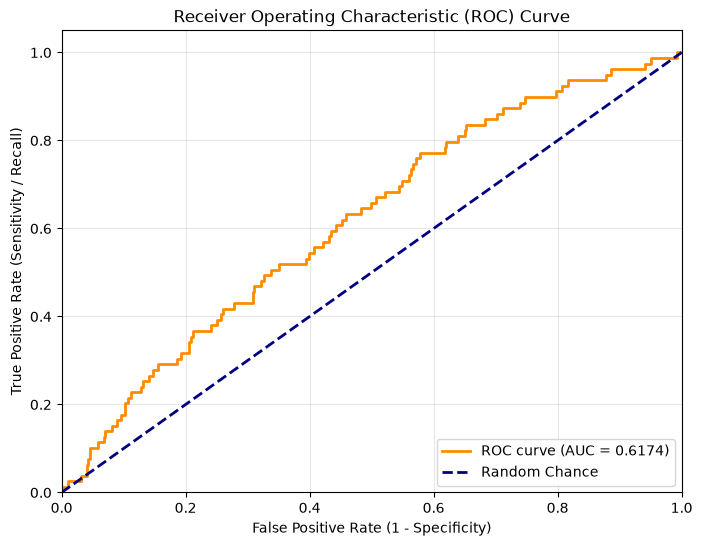

-----  Train  -----
Model F1 score: 0.0168
Model accuracy: 0.9595
[[8308  275]
 [  76    3]]



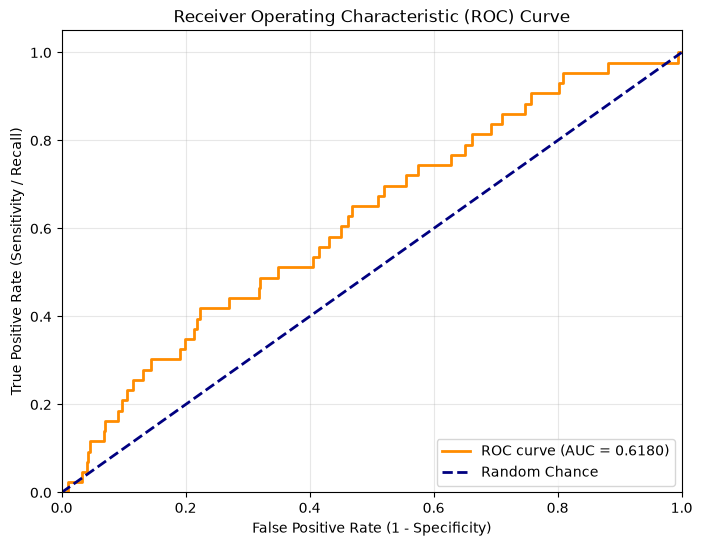

-----  Val  -----
Model F1 score: 0.0212
Model accuracy: 0.9573
[[4144  144]
 [  41    2]]



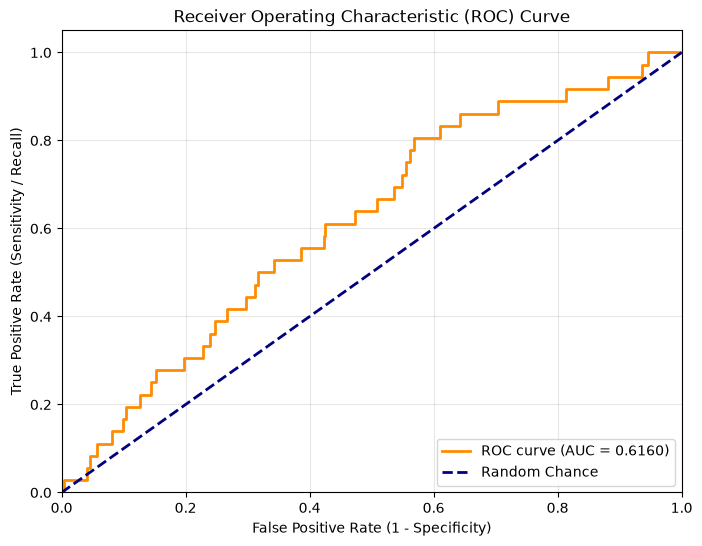

-----  Test  -----
Model F1 score: 0.0119
Model accuracy: 0.9617
[[4164  131]
 [  35    1]]

------------------------------------


------------------------------------
XGBoost - 100
------------------------------------


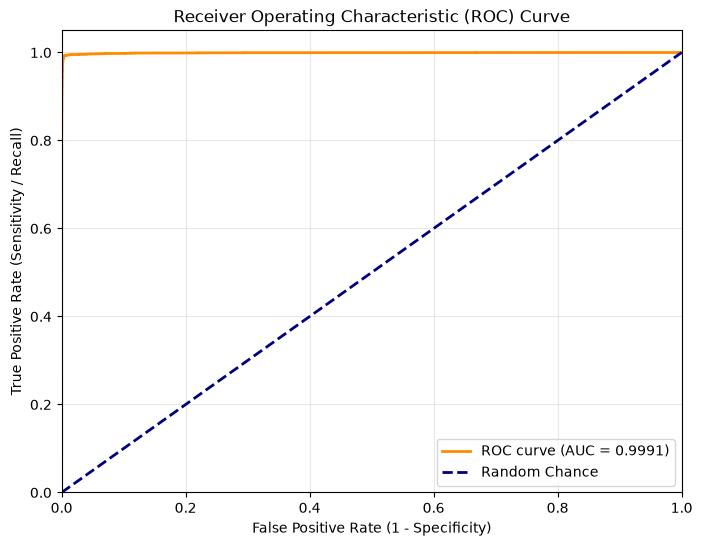

-----  Trainsm  -----
Model F1 score: 0.9922
Model accuracy: 0.9921
[[8498   85]
 [  50 8533]]



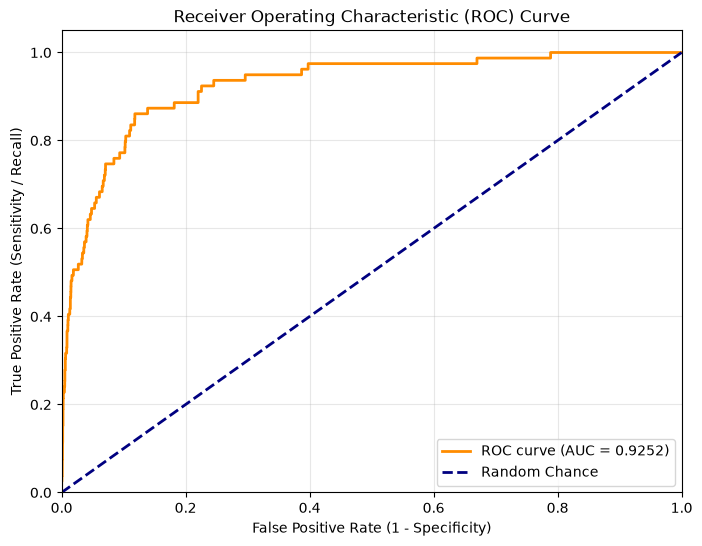

-----  Train  -----
Model F1 score: 0.3005
Model accuracy: 0.9844
[[8498   85]
 [  50   29]]



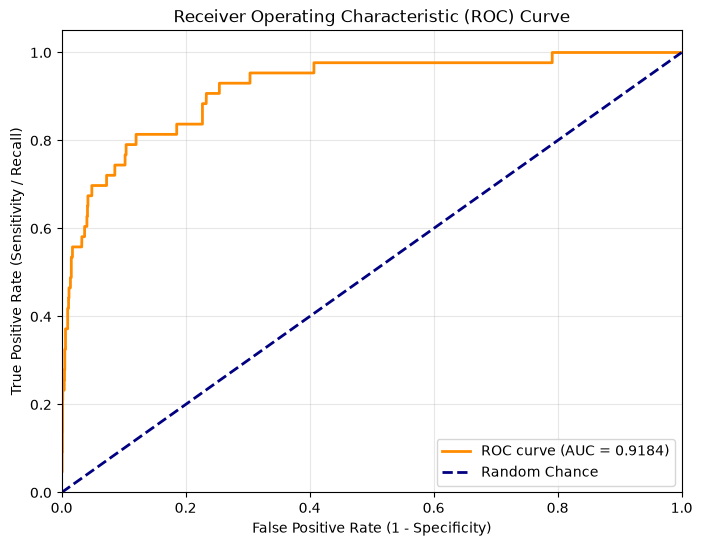

-----  Val  -----
Model F1 score: 0.3333
Model accuracy: 0.9834
[[4241   47]
 [  25   18]]



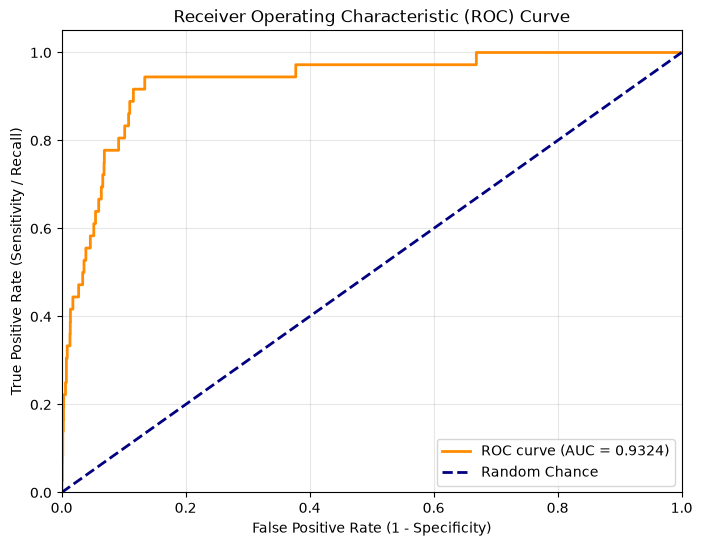

-----  Test  -----
Model F1 score: 0.2588
Model accuracy: 0.9855
[[4257   38]
 [  25   11]]

------------------------------------




In [34]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)
    model_body = clf.steps[-1][1] if hasattr(clf, 'steps') else clf
    if "LogisticRegression" in str(type(model_body)):
        
        explainer = shap.LinearExplainer(model_body, X_train_sm)
        shap_values = explainer(X_test)
    else:
        explainer = shap.TreeExplainer(model_body)
        shap_values = explainer(X_test)
    

    exp_res = {
        "name": name,
        "clf": clf,
        "explainer": explainer,
        "shap_values": shap_values
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 1]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 1, 0)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [35]:
res_df_all = pd.DataFrame.from_records(results)

# exclude explainer and shap_values 
columns_to_show = [col for col in res_df_all.columns if col not in ["explainer", "shap_values"]]
res_df = res_df_all[columns_to_show]


# sort by F1 score
res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df.to_excel("90_days_rf_lr_dt_xgboost.xlsx")

res_df

,name,clf,Trainsm_f1sore,Trainsm_acc,Trainsm_auc,Trainsm_tn,Trainsm_fp,Trainsm_fn,Trainsm_tp,Train_f1sore,...,Val_fp,Val_fn,Val_tp,Test_f1sore,Test_acc,Test_auc,Test_tn,Test_fp,Test_fn,Test_tp
6,XGBoost - 100,"XGBClassifier(alpha=10, base_score=None, boost...",0.992152,0.992136,0.999147,8498,85,50,8533,0.300518,...,47,25,18,0.258824,0.985454,0.932438,4257,38,25,11
0,DT - gini,"DecisionTreeClassifier(max_depth=10, random_st...",0.954976,0.953804,0.980097,7963,620,173,8410,0.167759,...,328,8,35,0.162465,0.930963,0.968445,4003,292,7,29
3,RF - gini_100,"(DecisionTreeClassifier(max_depth=10, max_feat...",0.960184,0.958639,0.997671,7895,688,22,8561,0.138350,...,367,12,31,0.135770,0.923574,0.939562,3974,321,10,26
4,RF - gini_150,"(DecisionTreeClassifier(criterion='entropy', m...",0.956206,0.954328,0.996841,7823,760,24,8559,0.123043,...,412,14,29,0.126829,0.917340,0.933980,3947,348,10,26
2,RF - gini_50,"(DecisionTreeClassifier(max_depth=10, max_feat...",0.954771,0.952755,0.997406,7795,788,23,8560,0.121343,...,415,14,29,0.123853,0.911799,0.930213,3922,373,9,27
1,DT - entropy,"DecisionTreeClassifier(criterion='entropy', ma...",0.944360,0.942386,0.959773,7784,799,190,8393,0.109795,...,423,14,29,0.101382,0.909952,0.925537,3919,376,14,22
5,LogReg,"(RobustScaler(), LogisticRegression(penalty='l...",0.947106,0.948153,0.984271,8308,275,615,7968,0.016807,...,144,41,2,0.011905,0.961672,0.616033,4164,131,35,1


In [36]:
from sklearn.preprocessing import StandardScaler

# L1 logistic regression and standarzation
X_scaled = StandardScaler().fit_transform(X_train_sm)
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42).fit(X_scaled, y_train_sm)

# generate odds ratio
df_res = pd.DataFrame({'Feature': X_train_sm.columns, 'Beta': model.coef_[0], 'Odds_Ratio': np.exp(model.coef_[0])})
df_res = df_res.iloc[df_res['Beta'].abs().argsort()[::-1]].round(4).reset_index(drop=True)


df_res.to_excel("90_days_odds_beta.xlsx")
df_res

c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Feature,Beta,Odds_Ratio
0,state_income_level_high,-4.2948,0.0136
1,state_income_level_low,-3.5407,0.0290
2,state_income_level_mid,-2.3223,0.0981
3,cat__product_cat_entertainment,-1.9332,0.1447
4,cat__product_cat_household,-1.7413,0.1753
5,cat__product_cat_beauty,-1.6676,0.1887
6,cat__order_status_delivered,-1.6630,0.1896
7,cat__product_cat_electronics,-1.3658,0.2552
8,freight_to_price_ratio,-1.1503,0.3165
9,product_photos_qty,-1.0374,0.3544


=== Displaying SHAP Summary Plot for Best Model: XGBoost - 100 ===


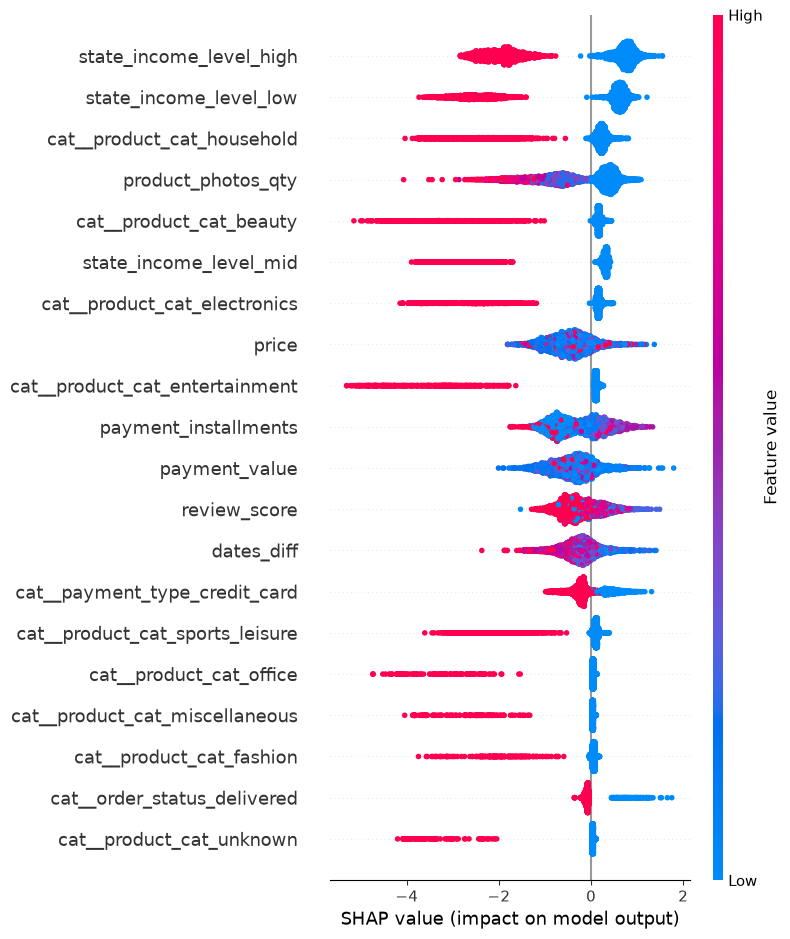

In [37]:

import shap

best_model_name = res_df.iloc[0]["name"]


target_res = next(item for item in results if item["name"] == best_model_name)

print(f"=== Displaying SHAP Summary Plot for Best Model: {target_res['name']} ===")

if target_res["shap_values"] is not None:

    shap.summary_plot(target_res["shap_values"], X_test)
else:
    print("This model does not have SHAP values calculated.")

--------
--------

## 120 days train_test dataset

In [38]:
Data_train_120_df["state_income_level"] = Data_train_120_df.customer_state.map(prov_income_map)

Data_train_120_df["state_income_level_high"] = (Data_train_120_df["state_income_level"] == "high").astype(int)
Data_train_120_df["state_income_level_mid"] = (Data_train_120_df["state_income_level"] == "mid").astype(int)
Data_train_120_df["state_income_level_low"] = (Data_train_120_df["state_income_level"] == "low").astype(int)

Data_train_120_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,delivered,1.0,credit_card,1.0,entertainment,0,high,1,0,0
1,01f156677184504063bd19739f924af1,739.98,0.060569,784.80,-46.0,5.0,0.002873,2.0,gravatal,SC,delivered,1.0,credit_card,10.0,household,0,low,0,0,1
2,0313291a6f4f16df04dcf819d88c38ef,95.00,0.187158,112.78,0.0,1.0,0.017780,1.0,sao sebastiao,SP,processing,1.0,boleto,1.0,household,0,high,1,0,0
3,0636d30c77f0f9cfad81f1c9b58c791f,949.99,0.023127,971.96,-44.0,4.0,0.004674,2.0,itaquaquecetuba,SP,delivered,1.0,credit_card,10.0,entertainment,0,high,1,0,0
4,0659f2d6cabae94afd4d009c6d0e07dc,390.00,0.177282,918.28,0.0,1.0,0.003582,1.0,cacequi,RS,canceled,1.0,credit_card,4.0,automotive,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,ffe2dd1f3b0cbf0b5f35e818ec03c49b,89.99,0.230137,110.70,-9.0,4.0,0.011834,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,2.0,household,0,high,1,0,0
7796,ffe3e199b9d0b7fb7d2d29a5b9498447,146.90,0.103472,162.10,0.0,1.0,0.043429,2.0,uberlandia,MG,delivered,1.0,boleto,1.0,construction,0,low,0,0,1
7797,ffebb6424578e7bb153322da9d65634f,629.00,0.058347,665.70,-5.0,1.0,0.005169,2.0,guarulhos,SP,delivered,1.0,credit_card,8.0,entertainment,0,high,1,0,0
7798,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0


In [39]:
target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop="first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_120_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [40]:
encoded_array = col_trans.transform(Data_train_120_df)

In [41]:
encoded_120_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_train_120_df.columns))

encoded_120_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__product_photos_qty,remainder__customer_city,remainder__customer_state,remainder__payment_sequential,remainder__payment_installments,remainder__churn_120,remainder__state_income_level,remainder__state_income_level_high,remainder__state_income_level_mid,remainder__state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,rio de janeiro,RJ,1.0,2.0,0,high,1,0,0
7796,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
7797,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,guarulhos,SP,1.0,8.0,0,high,1,0,0
7798,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0


In [42]:
encoded_120_df.columns = encoded_120_df.columns.str.replace('remainder__', '')

encoded_120_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,product_photos_qty,customer_city,customer_state,payment_sequential,payment_installments,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,rio de janeiro,RJ,1.0,2.0,0,high,1,0,0
7796,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
7797,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,guarulhos,SP,1.0,8.0,0,high,1,0,0
7798,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0


-----

## Test dataset

In [43]:
Data_test_120_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
1,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0
2,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0
3,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0
4,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,ffe76cb2f4bb39384c432d65ece67441,49.00,0.348163,66.06,-15.0,5.0,0.068240,3.0,camacari,BA,delivered,1.0,boleto,1.0,beauty,0
39953,ffec10ad4229ba46818560e1c8b40a68,120.00,0.131000,135.72,-10.0,5.0,0.104800,1.0,viana,ES,delivered,1.0,credit_card,3.0,sports_leisure,0
39954,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0
39955,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0


In [44]:
Data_test_120_df["state_income_level"] = Data_test_120_df.customer_state.map(prov_income_map)

Data_test_120_df["state_income_level_high"] = (Data_test_120_df["state_income_level"] == "high").astype(int)
Data_test_120_df["state_income_level_mid"] = (Data_test_120_df["state_income_level"] == "mid").astype(int)
Data_test_120_df["state_income_level_low"] = (Data_test_120_df["state_income_level"] == "low").astype(int)

Data_test_120_df 

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
1,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0,low,0,0,1
2,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
3,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0,low,0,0,1
4,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,ffe76cb2f4bb39384c432d65ece67441,49.00,0.348163,66.06,-15.0,5.0,0.068240,3.0,camacari,BA,delivered,1.0,boleto,1.0,beauty,0,mid,0,1,0
39953,ffec10ad4229ba46818560e1c8b40a68,120.00,0.131000,135.72,-10.0,5.0,0.104800,1.0,viana,ES,delivered,1.0,credit_card,3.0,sports_leisure,0,mid,0,1,0
39954,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0,high,1,0,0
39955,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0,high,1,0,0


In [45]:
encoded_array_test = col_trans.transform(Data_test_120_df)

In [46]:
encoded_120_test_df = pd.DataFrame(encoded_array_test, columns= col_trans.get_feature_names_out(Data_test_120_df.columns))

encoded_120_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__product_photos_qty,remainder__customer_city,remainder__customer_state,remainder__payment_sequential,remainder__payment_installments,remainder__churn_120,remainder__state_income_level,remainder__state_income_level_high,remainder__state_income_level_mid,remainder__state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,curitiba,PR,1.0,3.0,0,low,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,sao luis,MA,1.0,4.0,0,low,0,0,1
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,campinas,SP,1.0,3.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,belo horizonte,MG,1.0,2.0,0,low,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,sao paulo,SP,1.0,1.0,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,camacari,BA,1.0,1.0,0,mid,0,1,0
39953,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,viana,ES,1.0,3.0,0,mid,0,1,0
39954,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,ilha solteira,SP,1.0,1.0,0,high,1,0,0
39955,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,rio de janeiro,RJ,1.0,8.0,0,high,1,0,0


In [47]:
encoded_120_test_df.columns = encoded_120_test_df.columns.str.replace('remainder__', '')

encoded_120_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,product_photos_qty,customer_city,customer_state,payment_sequential,payment_installments,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,curitiba,PR,1.0,3.0,0,low,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,sao luis,MA,1.0,4.0,0,low,0,0,1
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,campinas,SP,1.0,3.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,belo horizonte,MG,1.0,2.0,0,low,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,sao paulo,SP,1.0,1.0,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,camacari,BA,1.0,1.0,0,mid,0,1,0
39953,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,viana,ES,1.0,3.0,0,mid,0,1,0
39954,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,ilha solteira,SP,1.0,1.0,0,high,1,0,0
39955,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,rio de janeiro,RJ,1.0,8.0,0,high,1,0,0


In [48]:
target_col = 'churn_120'

encoded_120_df[target_col] = encoded_120_df[target_col].astype(int)


for col in encoded_120_df.columns:
    if col != target_col:

        encoded_120_df[col] = pd.to_numeric(encoded_120_df[col], errors='coerce')


corr_matrix = encoded_120_df.corr(numeric_only=True)

churn_relationships = corr_matrix[target_col].drop(target_col)


feature_relation_table = pd.DataFrame({
    'Feature_Name': churn_relationships.index,
    'Correlation_Value': churn_relationships.values,
    'Absolute_Correlation': churn_relationships.abs().values
})

In [49]:
feature_relation_table.to_excel("features_churn_corr_120.xlsx")

In [50]:
feature_relation_table.to_excel("feature_churn_corr_table_90.xlsx")

-----

## Train test split

In [51]:
X_train = encoded_120_test_df.drop(columns = ['churn_120', "customer_unique_id", "customer_city", "customer_state", "state_income_level"])

y_train = encoded_120_test_df['churn_120'].fillna(0).astype(int)

In [52]:
X_valtest = encoded_120_test_df.drop(columns = ['churn_120', "customer_unique_id", "customer_city", "customer_state", "state_income_level"])

y_valtest = encoded_120_test_df['churn_120'].fillna(0).astype(int)

In [53]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, test_size= 0.5, random_state = 42)

In [54]:
print(X_train.shape)
print(X_valtest.shape)

(39957, 36)
(39957, 36)


In [55]:
X_train = X_train.astype(int)

X_val = X_val.astype(int)

X_test = X_test.astype(int)

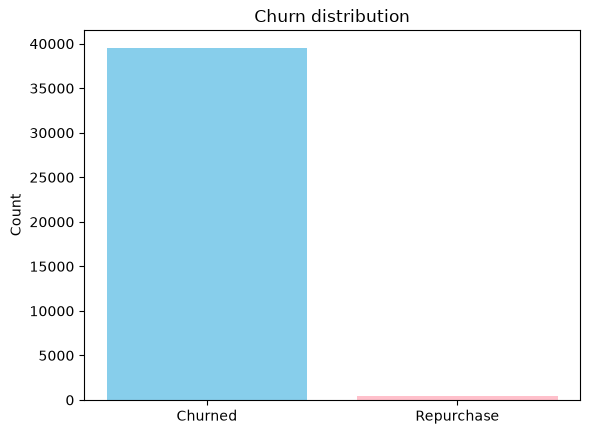

In [56]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchase"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [57]:
X_valtest.columns

Index(['cat__order_status_canceled', 'cat__order_status_delivered',
       'cat__order_status_invoiced', 'cat__order_status_processing',
       'cat__order_status_shipped', 'cat__order_status_unavailable',
       'cat__payment_type_credit_card', 'cat__payment_type_debit_card',
       'cat__payment_type_voucher', 'cat__product_cat_babies',
       'cat__product_cat_beauty', 'cat__product_cat_books_media',
       'cat__product_cat_commercial_industrial',
       'cat__product_cat_construction', 'cat__product_cat_electronics',
       'cat__product_cat_entertainment', 'cat__product_cat_fashion',
       'cat__product_cat_food_drink', 'cat__product_cat_household',
       'cat__product_cat_miscellaneous', 'cat__product_cat_office',
       'cat__product_cat_pet_shop', 'cat__product_cat_sports_leisure',
       'cat__product_cat_unknown', 'price', 'freight_to_price_ratio',
       'payment_value', 'dates_diff', 'review_score',
       'freight_to_weight_ratio', 'product_photos_qty', 'payment_sequent

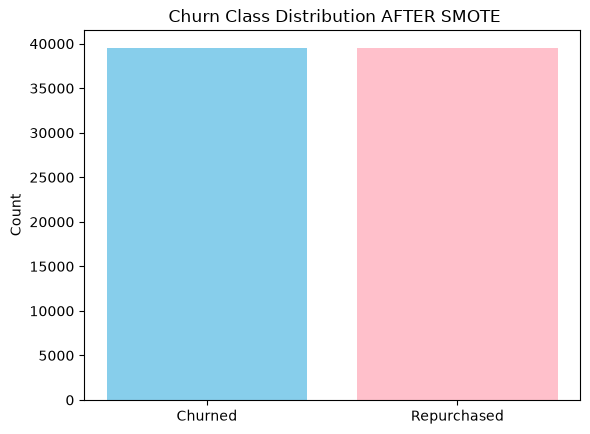

In [58]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

------------------------------------
DT - gini
------------------------------------


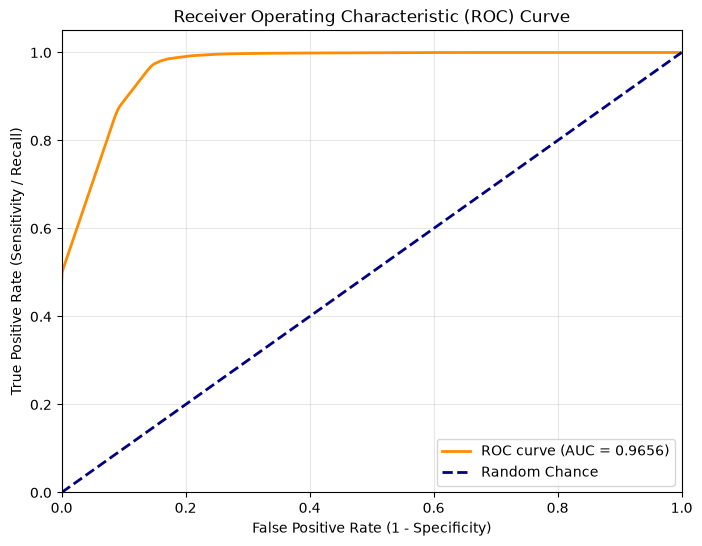

-----  Trainsm  -----
Model F1 score: 0.9174
Model accuracy: 0.9123
[[33608  5917]
 [ 1014 38511]]



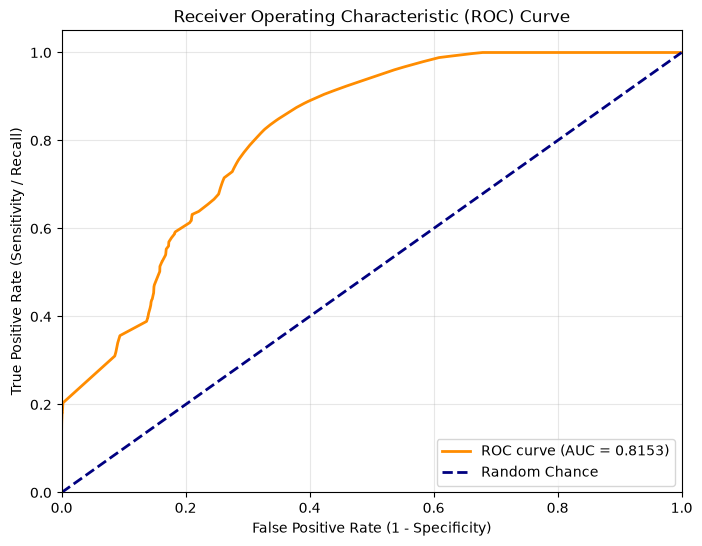

-----  Train  -----
Model F1 score: 0.0623
Model accuracy: 0.8462
[[33608  5917]
 [  228   204]]



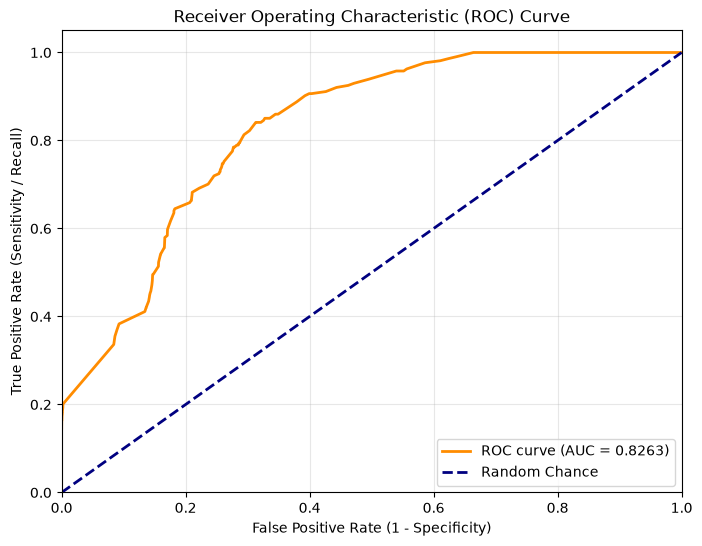

-----  Val  -----
Model F1 score: 0.0655
Model accuracy: 0.8486
[[16848  2916]
 [  108   106]]



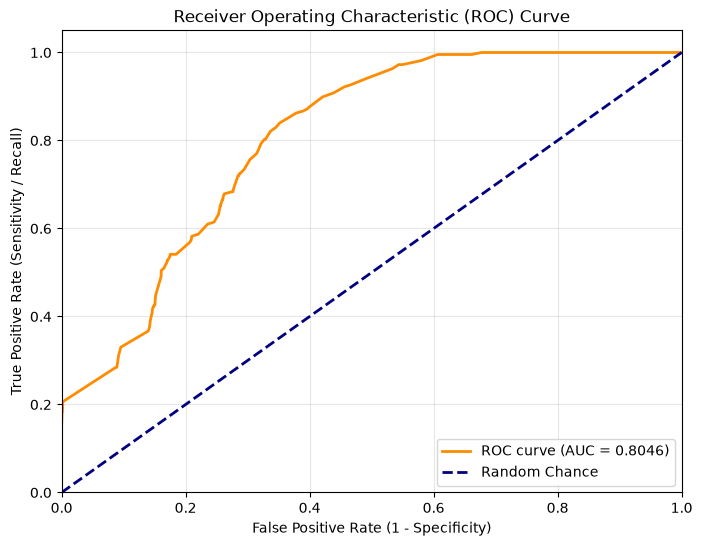

-----  Test  -----
Model F1 score: 0.0591
Model accuracy: 0.8438
[[16760  3001]
 [  120    98]]

------------------------------------


------------------------------------
DT - entropy
------------------------------------


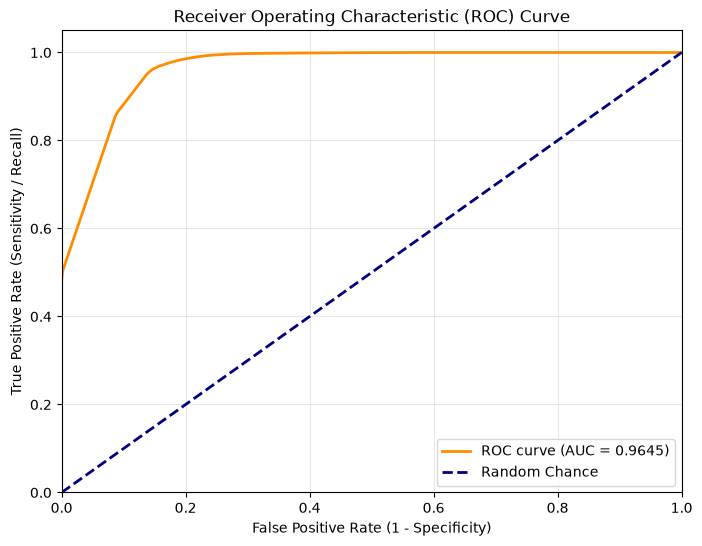

-----  Trainsm  -----
Model F1 score: 0.9123
Model accuracy: 0.9075
[[33712  5813]
 [ 1497 38028]]



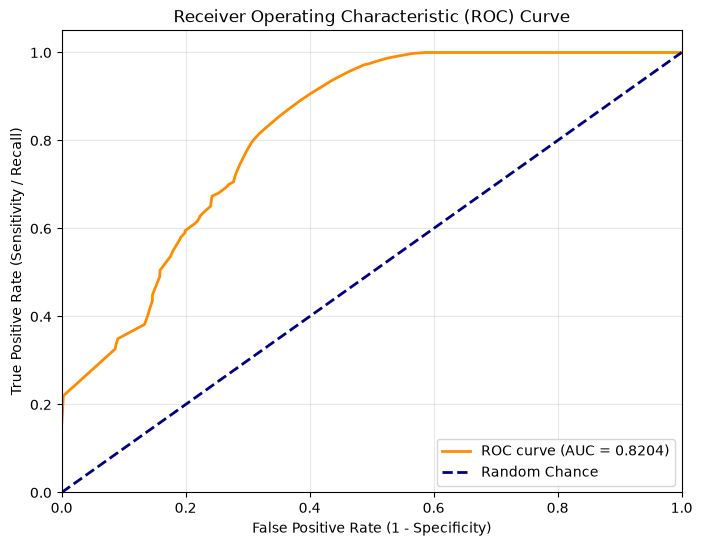

-----  Train  -----
Model F1 score: 0.0606
Model accuracy: 0.8486
[[33712  5813]
 [  237   195]]



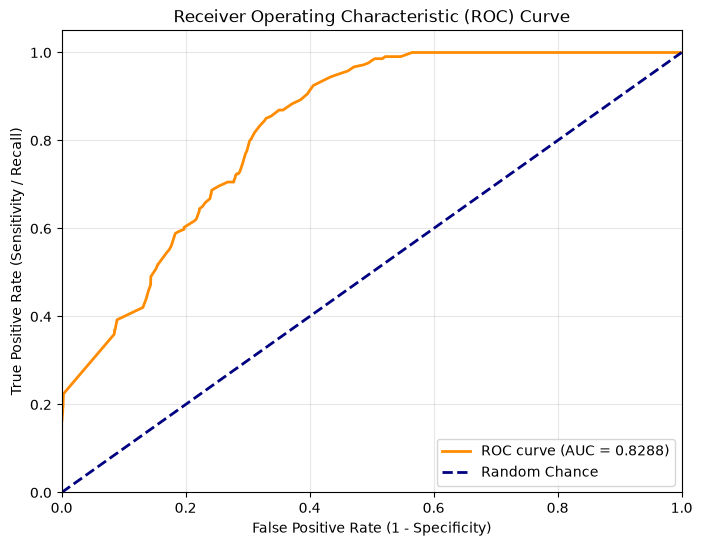

-----  Val  -----
Model F1 score: 0.0664
Model accuracy: 0.8521
[[16919  2845]
 [  109   105]]



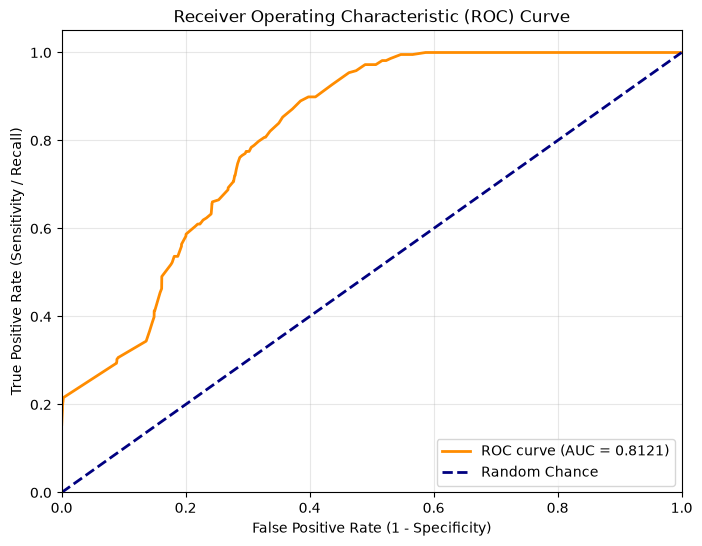

-----  Test  -----
Model F1 score: 0.0549
Model accuracy: 0.8450
[[16793  2968]
 [  128    90]]

------------------------------------


------------------------------------
RF - gini_50
------------------------------------


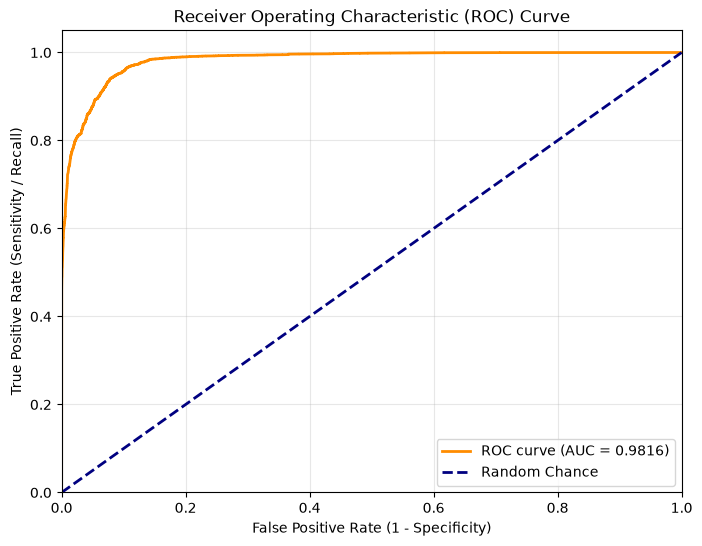

-----  Trainsm  -----
Model F1 score: 0.9271
Model accuracy: 0.9230
[[34306  5219]
 [  864 38661]]



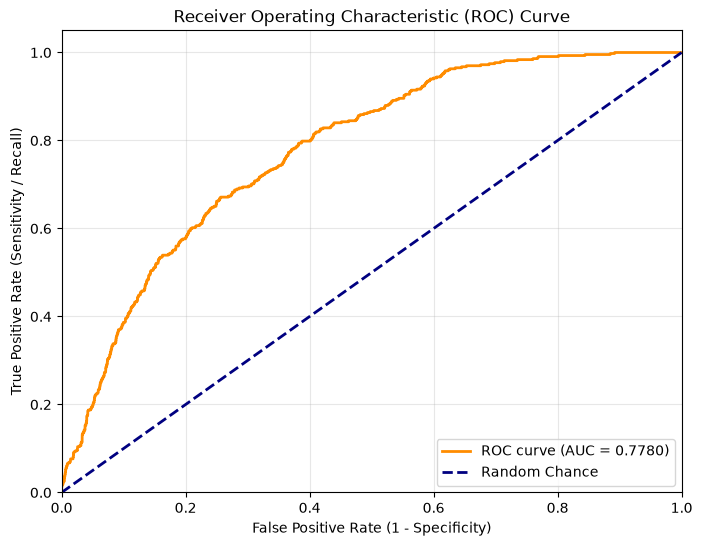

-----  Train  -----
Model F1 score: 0.0677
Model accuracy: 0.8635
[[34306  5219]
 [  234   198]]



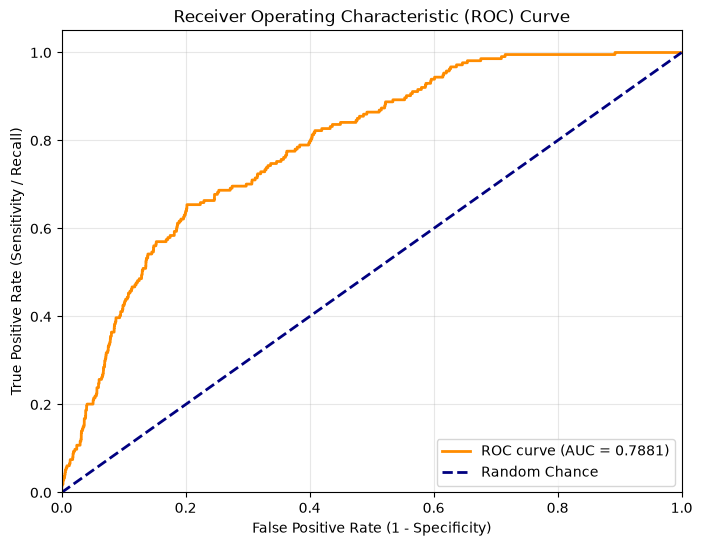

-----  Val  -----
Model F1 score: 0.0733
Model accuracy: 0.8684
[[17244  2520]
 [  110   104]]



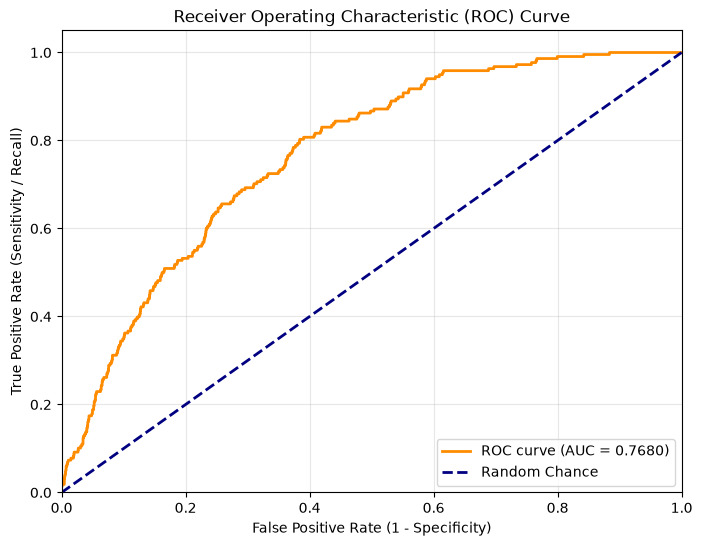

-----  Test  -----
Model F1 score: 0.0624
Model accuracy: 0.8587
[[17062  2699]
 [  124    94]]

------------------------------------


------------------------------------
RF - gini_100
------------------------------------


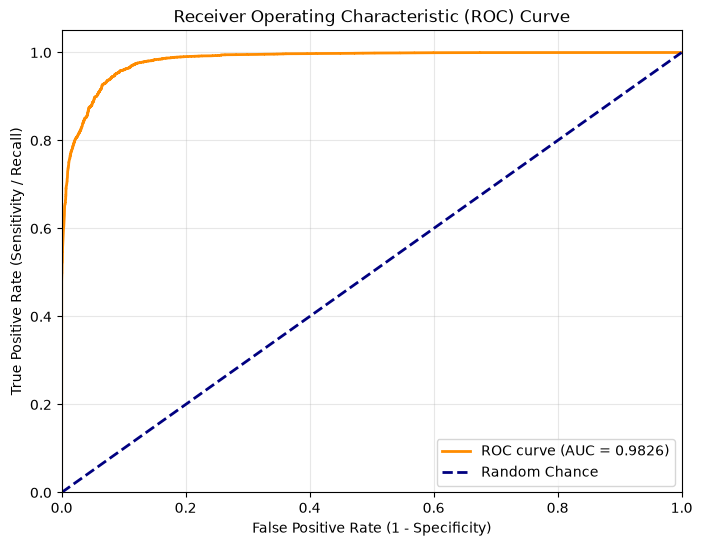

-----  Trainsm  -----
Model F1 score: 0.9279
Model accuracy: 0.9240
[[34392  5133]
 [  876 38649]]



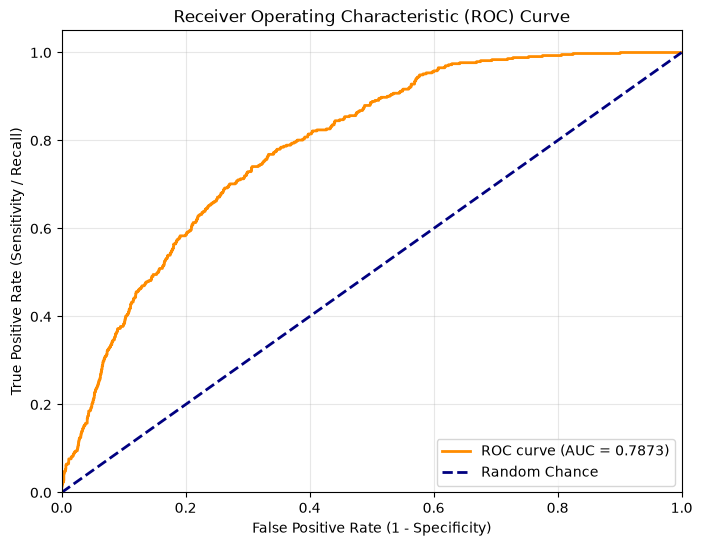

-----  Train  -----
Model F1 score: 0.0701
Model accuracy: 0.8658
[[34392  5133]
 [  230   202]]



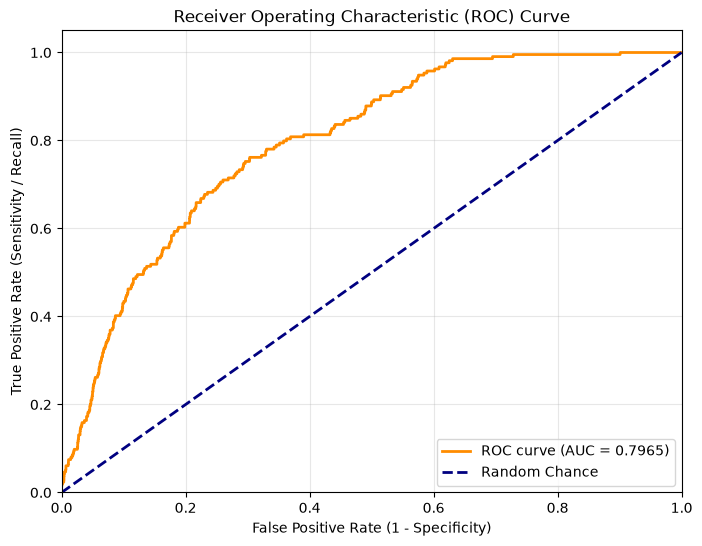

-----  Val  -----
Model F1 score: 0.0752
Model accuracy: 0.8695
[[17265  2499]
 [  108   106]]



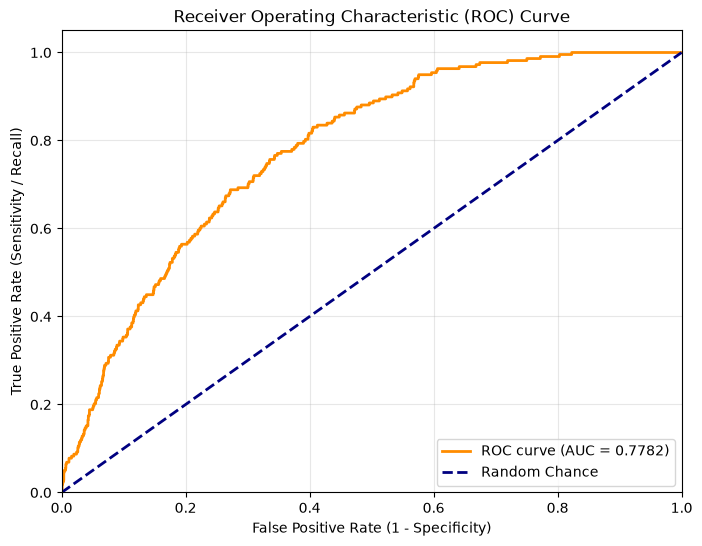

-----  Test  -----
Model F1 score: 0.0651
Model accuracy: 0.8621
[[17127  2634]
 [  122    96]]

------------------------------------


------------------------------------
RF - gini_150
------------------------------------


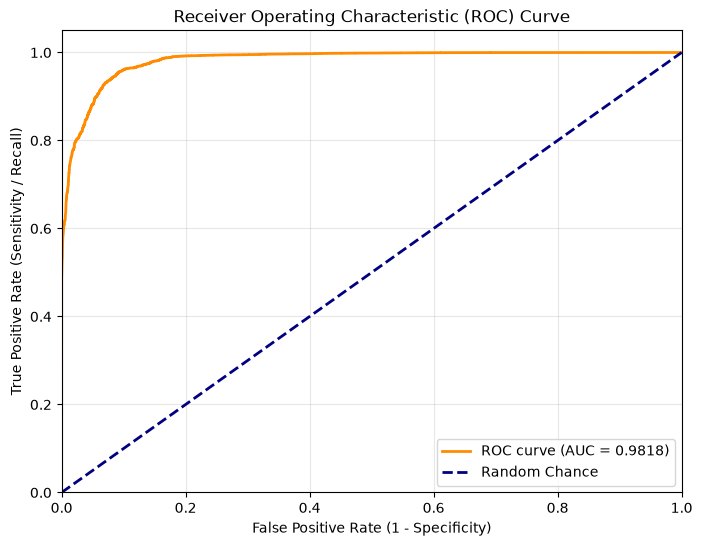

-----  Trainsm  -----
Model F1 score: 0.9218
Model accuracy: 0.9173
[[33981  5544]
 [  992 38533]]



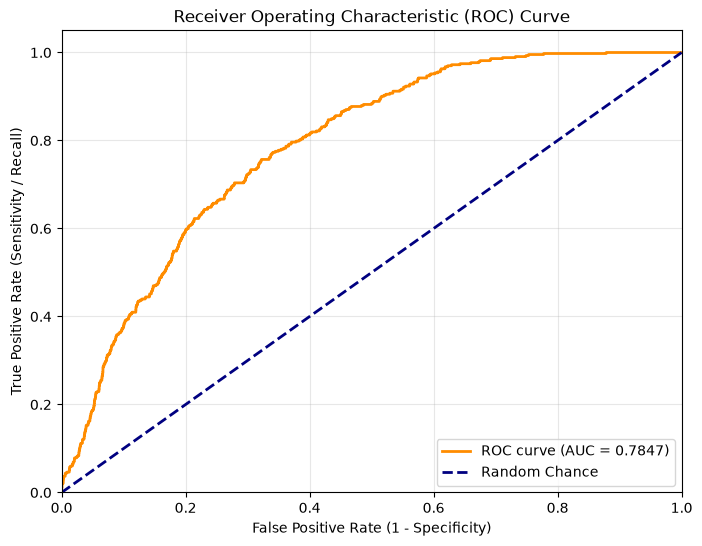

-----  Train  -----
Model F1 score: 0.0623
Model accuracy: 0.8552
[[33981  5544]
 [  240   192]]



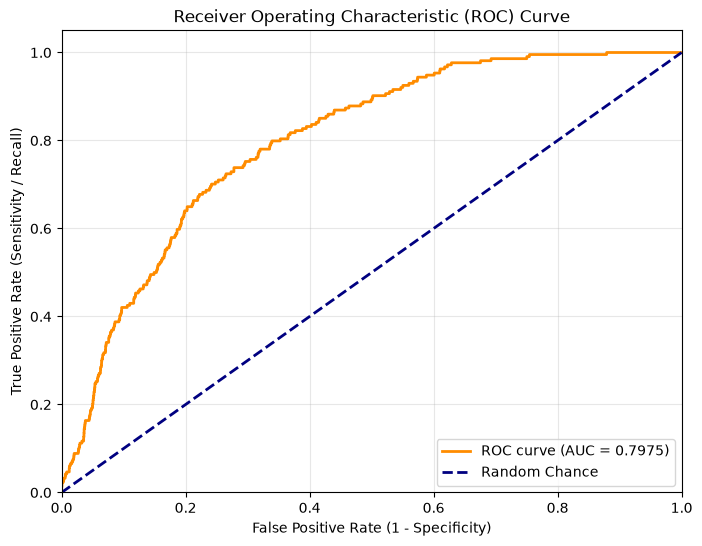

-----  Val  -----
Model F1 score: 0.0671
Model accuracy: 0.8594
[[17069  2695]
 [  113   101]]



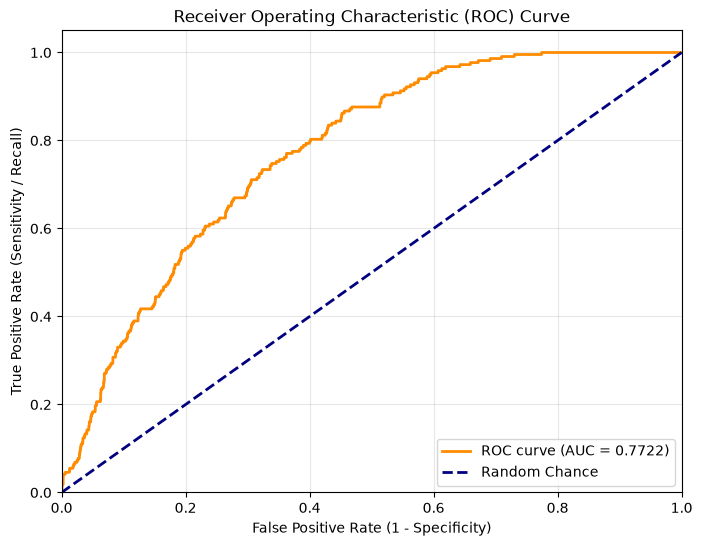

-----  Test  -----
Model F1 score: 0.0576
Model accuracy: 0.8510
[[16912  2849]
 [  127    91]]

------------------------------------




c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

------------------------------------
LogReg
------------------------------------


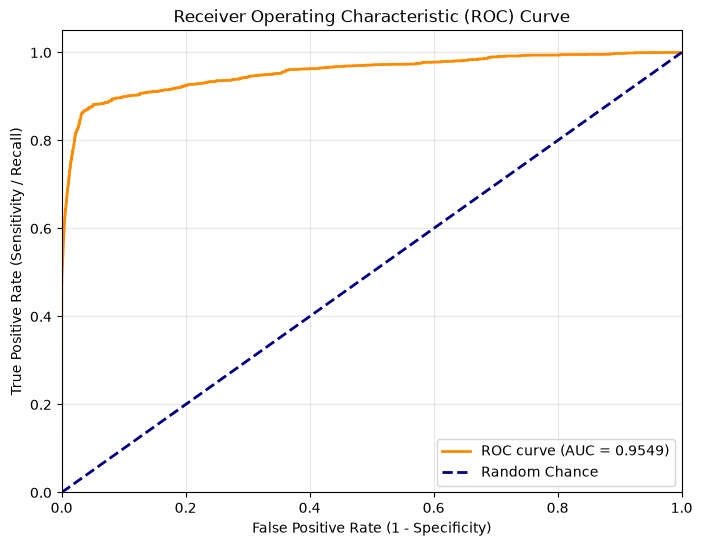

-----  Trainsm  -----
Model F1 score: 0.9112
Model accuracy: 0.9148
[[37782  1743]
 [ 4989 34536]]



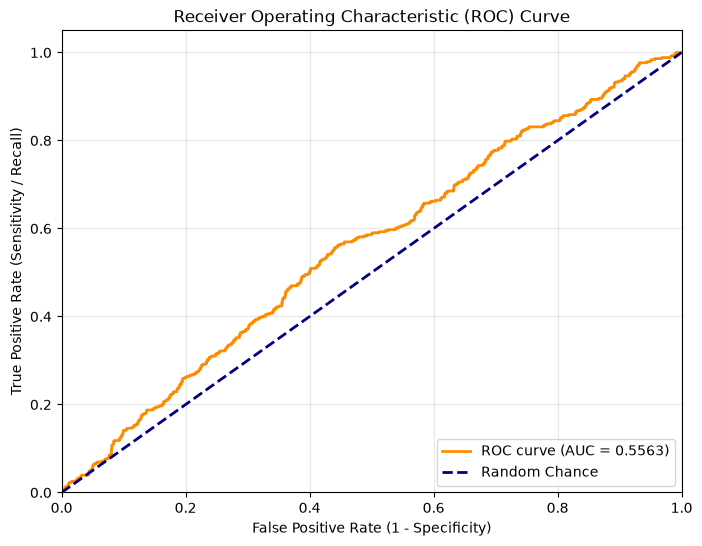

-----  Train  -----
Model F1 score: 0.0173
Model accuracy: 0.9460
[[37782  1743]
 [  413    19]]



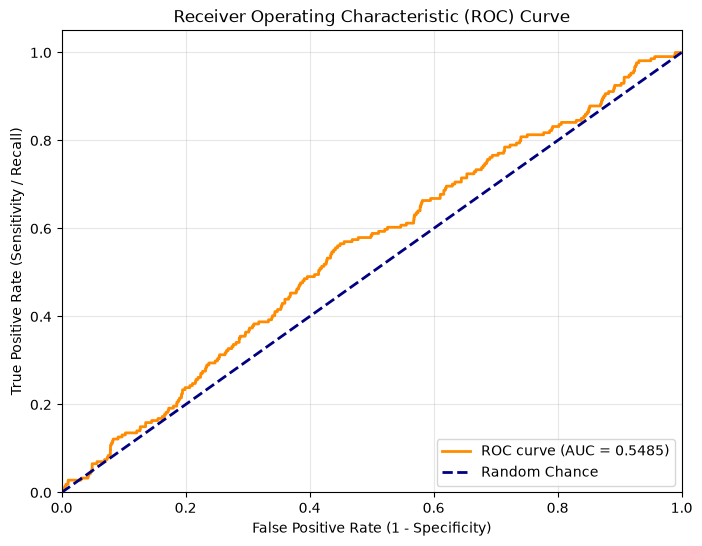

-----  Val  -----
Model F1 score: 0.0149
Model accuracy: 0.9470
[[18911   853]
 [  206     8]]



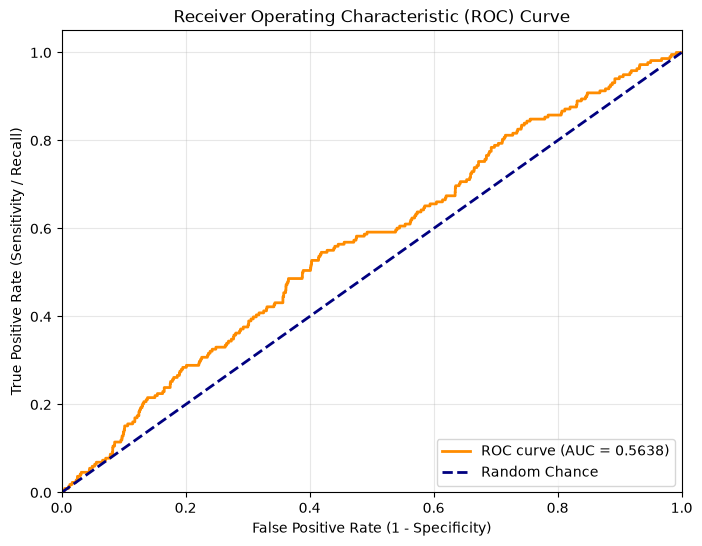

-----  Test  -----
Model F1 score: 0.0197
Model accuracy: 0.9451
[[18871   890]
 [  207    11]]

------------------------------------


------------------------------------
XGBoost - 100
------------------------------------


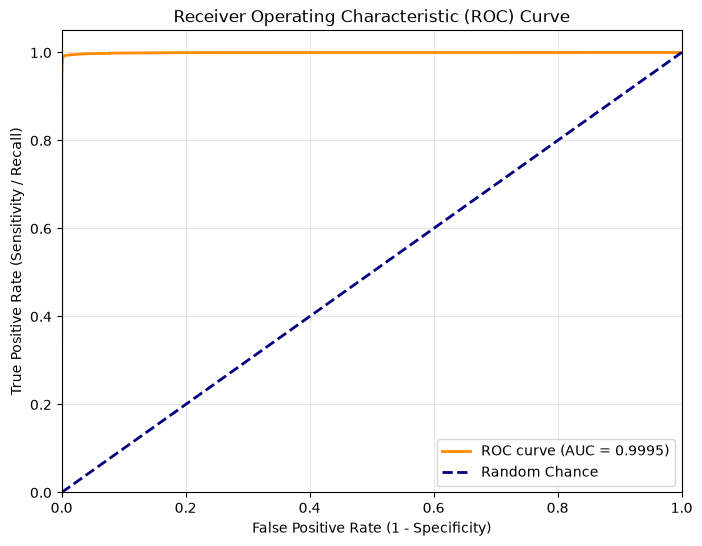

-----  Trainsm  -----
Model F1 score: 0.9922
Model accuracy: 0.9922
[[39145   380]
 [  240 39285]]



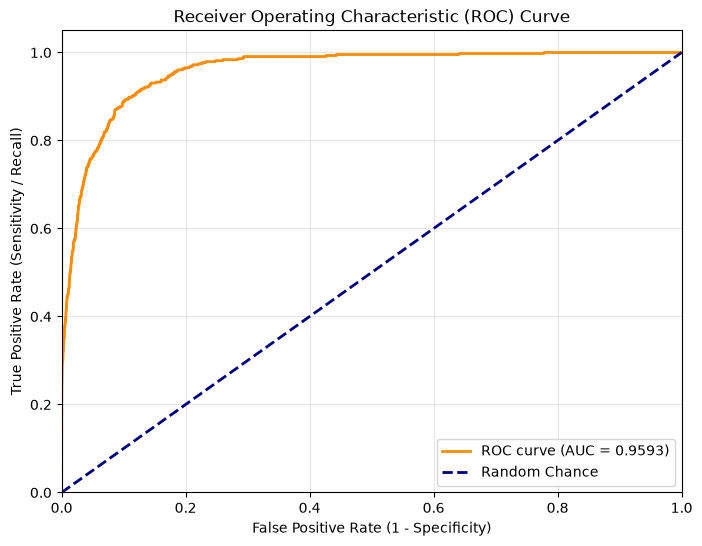

-----  Train  -----
Model F1 score: 0.3857
Model accuracy: 0.9845
[[39145   380]
 [  238   194]]



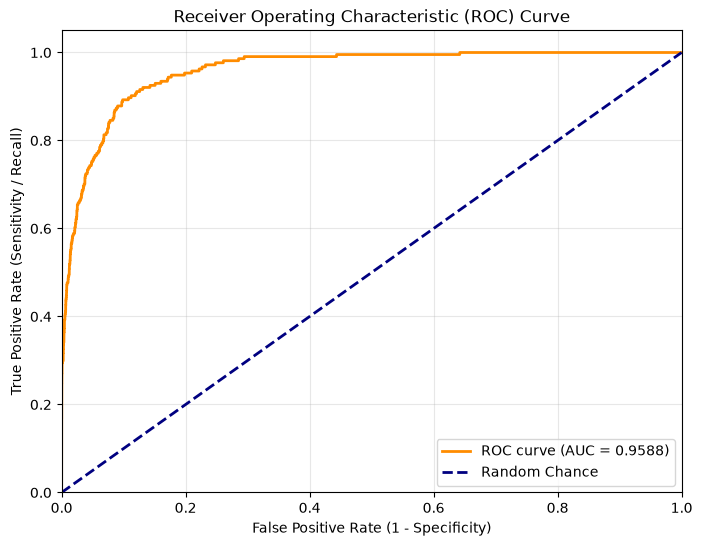

-----  Val  -----
Model F1 score: 0.4130
Model accuracy: 0.9855
[[19586   178]
 [  112   102]]



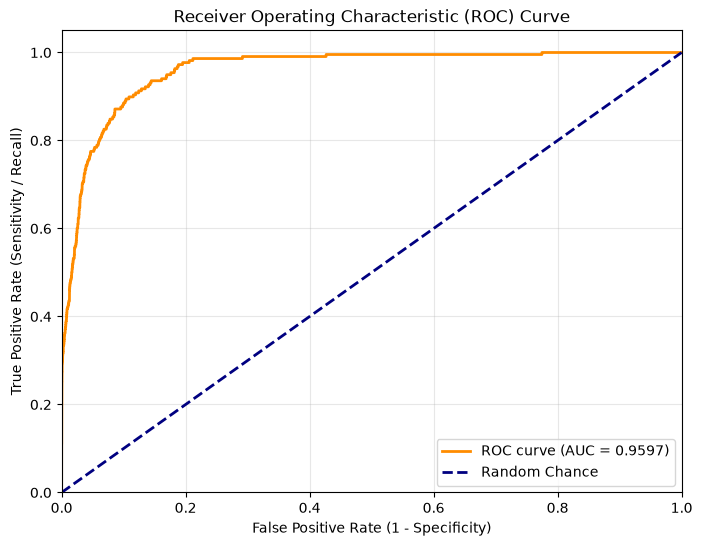

-----  Test  -----
Model F1 score: 0.3594
Model accuracy: 0.9836
[[19559   202]
 [  126    92]]

------------------------------------




In [59]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)
    model_body = clf.steps[-1][1] if hasattr(clf, 'steps') else clf
    if "LogisticRegression" in str(type(model_body)):
        
        explainer = shap.LinearExplainer(model_body, X_train_sm)
        shap_values = explainer(X_test)
    else:
        explainer = shap.TreeExplainer(model_body)
        shap_values = explainer(X_test)
    

    exp_res = {
        "name": name,
        "clf": clf,
        "explainer": explainer,
        "shap_values": shap_values
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 1]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 1, 0)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [ ]:
res_df_all = pd.DataFrame.from_records(results)

columns_to_show = [col for col in res_df_all.columns if col not in ["explainer", "shap_values"]]
res_df = res_df_all[columns_to_show]

res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df.to_excel("120_days_rf_lr_dt_xgboost.xlsx")

In [61]:
from sklearn.preprocessing import StandardScaler


X_scaled = StandardScaler().fit_transform(X_train_sm)
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42).fit(X_scaled, y_train_sm)


df_res = pd.DataFrame({'Feature': X_train_sm.columns, 'Beta': model.coef_[0], 'Odds_Ratio': np.exp(model.coef_[0])})
df_res = df_res.iloc[df_res['Beta'].abs().argsort()[::-1]].round(4).reset_index(drop=True)


df_res.to_excel("120_days_odds_beta.xlsx")

c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


=== Displaying SHAP Summary Plot for Best Model: RF - gini_150 ===


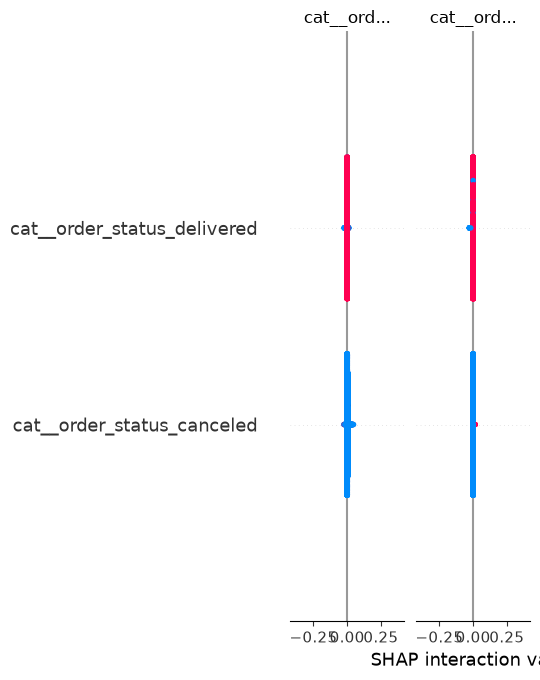

In [97]:
best_model_name = res_df.iloc[0]["name"]


target_res = next(item for item in results if item["name"] == best_model_name)

print(f"=== Displaying SHAP Summary Plot for Best Model: {target_res['name']} ===")


if target_res["shap_values"] is not None:
   
    shap.summary_plot(target_res["shap_values"], X_test)
else:
    print("This model does not have SHAP values calculated.")

----
----

## 150 days

## 150 days train_test dataset

In [63]:
Data_train_150_df["state_income_level"] = Data_train_150_df.customer_state.map(prov_income_map)

Data_train_150_df["state_income_level_high"] = (Data_train_150_df["state_income_level"] == "high").astype(int)
Data_train_150_df["state_income_level_mid"] = (Data_train_150_df["state_income_level"] == "mid").astype(int)
Data_train_150_df["state_income_level_low"] = (Data_train_150_df["state_income_level"] == "low").astype(int)

Data_train_150_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,0.030705,6.0,brasilia,DF,delivered,1.0,credit_card,1.0,sports_leisure,0,low,0,0,1
1,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,delivered,1.0,credit_card,1.0,entertainment,0,high,1,0,0
2,008f3d5f45a11059239a5c452cd00006,309.90,0.086028,336.56,-28.0,5.0,0.059376,1.0,sao pedro da agua branca,MA,delivered,1.0,boleto,1.0,beauty,0,low,0,0,1
3,012e12f54f6e73b1faba89a119dab849,87.74,0.205152,105.74,-40.0,4.0,0.006207,10.0,maurilandia,GO,delivered,1.0,credit_card,5.0,household,0,low,0,0,1
4,01838e7d69d87bd8ff2b6ff06789adfb,126.90,0.253822,159.11,-35.0,5.0,0.035789,2.0,belem,PA,delivered,1.0,credit_card,1.0,fashion,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14367,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
14368,ffef0ffa736c7b3d9af741611089729b,109.90,0.265423,139.07,-22.0,5.0,0.025678,1.0,nova venecia,ES,delivered,1.0,credit_card,1.0,sports_leisure,0,mid,0,1,0
14369,fffcf5a5ff07b0908bd4e2dbc735a684,1570.00,0.320939,4134.84,-27.0,5.0,0.008290,1.0,sanharo,PE,delivered,1.0,credit_card,10.0,beauty,0,mid,0,1,0
14370,ffff371b4d645b6ecea244b27531430a,89.90,0.250945,112.46,-30.0,5.0,0.037600,5.0,sinop,MT,delivered,1.0,credit_card,1.0,automotive,0,low,0,0,1


In [64]:
target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop= "first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_150_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [65]:
encoded_array = col_trans.transform(Data_train_150_df)

In [66]:
encoded_150_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_train_150_df.columns))

encoded_150_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__product_photos_qty,remainder__customer_city,remainder__customer_state,remainder__payment_sequential,remainder__payment_installments,remainder__churn_150,remainder__state_income_level,remainder__state_income_level_high,remainder__state_income_level_mid,remainder__state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,6.0,brasilia,DF,1.0,1.0,0,low,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao pedro da agua branca,MA,1.0,1.0,0,low,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,10.0,maurilandia,GO,1.0,5.0,0,low,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,belem,PA,1.0,1.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14367,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
14368,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0
14369,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,sanharo,PE,1.0,10.0,0,mid,0,1,0
14370,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,5.0,sinop,MT,1.0,1.0,0,low,0,0,1


In [67]:
encoded_150_df.columns = encoded_150_df.columns.str.replace('remainder__', '')

encoded_150_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,product_photos_qty,customer_city,customer_state,payment_sequential,payment_installments,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,6.0,brasilia,DF,1.0,1.0,0,low,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao pedro da agua branca,MA,1.0,1.0,0,low,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,10.0,maurilandia,GO,1.0,5.0,0,low,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,belem,PA,1.0,1.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14367,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
14368,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0
14369,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,sanharo,PE,1.0,10.0,0,mid,0,1,0
14370,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,5.0,sinop,MT,1.0,1.0,0,low,0,0,1


----

## Test dataset

In [68]:
Data_test_150_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150
0,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,0.004327,3.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0
1,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,0.024633,6.0,campinas,SP,delivered,1.0,boleto,1.0,electronics,0
2,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
3,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0
4,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,fff7219c86179ca6441b8f37823ba3d3,245.80,0.081367,531.60,-12.0,4.0,0.005714,1.0,cachoeiras de macacu,RJ,delivered,1.0,debit_card,1.0,household,0
32715,fffb09418989a0dbff854a28163e47c6,58.00,0.261379,73.16,-23.0,5.0,0.071174,1.0,veranopolis,RS,delivered,1.0,boleto,1.0,beauty,0
32716,fffbf87b7a1a6fa8b03f081c5f51a201,149.00,0.122953,167.32,-14.0,5.0,0.052343,0.0,fortaleza,CE,delivered,1.0,credit_card,2.0,unknown,0
32717,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0


In [69]:
Data_test_150_df["state_income_level"] = Data_test_150_df.customer_state.map(prov_income_map)

Data_test_150_df["state_income_level_high"] = (Data_test_150_df["state_income_level"] == "high").astype(int)
Data_test_150_df["state_income_level_mid"] = (Data_test_150_df["state_income_level"] == "mid").astype(int)
Data_test_150_df["state_income_level_low"] = (Data_test_150_df["state_income_level"] == "low").astype(int)

Data_test_150_df 

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,0.004327,3.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0,high,1,0,0
1,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,0.024633,6.0,campinas,SP,delivered,1.0,boleto,1.0,electronics,0,high,1,0,0
2,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
3,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0,low,0,0,1
4,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,fff7219c86179ca6441b8f37823ba3d3,245.80,0.081367,531.60,-12.0,4.0,0.005714,1.0,cachoeiras de macacu,RJ,delivered,1.0,debit_card,1.0,household,0,high,1,0,0
32715,fffb09418989a0dbff854a28163e47c6,58.00,0.261379,73.16,-23.0,5.0,0.071174,1.0,veranopolis,RS,delivered,1.0,boleto,1.0,beauty,0,low,0,0,1
32716,fffbf87b7a1a6fa8b03f081c5f51a201,149.00,0.122953,167.32,-14.0,5.0,0.052343,0.0,fortaleza,CE,delivered,1.0,credit_card,2.0,unknown,0,mid,0,1,0
32717,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0,high,1,0,0


In [70]:
encoded_array_test = col_trans.transform(Data_test_150_df)

In [71]:
encoded_150_test_df = pd.DataFrame(encoded_array_test, columns= col_trans.get_feature_names_out(Data_test_150_df.columns))

encoded_150_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__product_photos_qty,remainder__customer_city,remainder__customer_state,remainder__payment_sequential,remainder__payment_installments,remainder__churn_150,remainder__state_income_level,remainder__state_income_level_high,remainder__state_income_level_mid,remainder__state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,sao paulo,SP,1.0,8.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,campinas,SP,1.0,1.0,0,high,1,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,curitiba,PR,1.0,3.0,0,low,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,sao luis,MA,1.0,4.0,0,low,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,campinas,SP,1.0,3.0,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,cachoeiras de macacu,RJ,1.0,1.0,0,high,1,0,0
32715,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,veranopolis,RS,1.0,1.0,0,low,0,0,1
32716,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,fortaleza,CE,1.0,2.0,0,mid,0,1,0
32717,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,2.0,cabo frio,RJ,1.0,3.0,0,high,1,0,0


In [72]:
encoded_150_test_df.columns = encoded_150_test_df.columns.str.replace('remainder__', '')

encoded_150_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,product_photos_qty,customer_city,customer_state,payment_sequential,payment_installments,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,sao paulo,SP,1.0,8.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,campinas,SP,1.0,1.0,0,high,1,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,curitiba,PR,1.0,3.0,0,low,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,sao luis,MA,1.0,4.0,0,low,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,campinas,SP,1.0,3.0,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,cachoeiras de macacu,RJ,1.0,1.0,0,high,1,0,0
32715,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,veranopolis,RS,1.0,1.0,0,low,0,0,1
32716,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,fortaleza,CE,1.0,2.0,0,mid,0,1,0
32717,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,2.0,cabo frio,RJ,1.0,3.0,0,high,1,0,0


In [73]:
target_col = 'churn_150'

encoded_150_df[target_col] = encoded_150_df[target_col].astype(int)


for col in encoded_150_df.columns:
    if col != target_col:

        encoded_150_df[col] = pd.to_numeric(encoded_150_df[col], errors='coerce')


corr_matrix = encoded_150_df.corr(numeric_only=True)

churn_relationships = corr_matrix[target_col].drop(target_col)


feature_relation_table = pd.DataFrame({
    'Feature_Name': churn_relationships.index,
    'Correlation_Value': churn_relationships.values,
    'Absolute_Correlation': churn_relationships.abs().values
})

In [74]:
feature_relation_table.to_excel("feature_churn_corr_table_150.xlsx")

-----

## Train test split

In [75]:
X_train = encoded_150_df.drop(columns = ['churn_150', "customer_unique_id", "customer_city", "customer_state", "state_income_level"])

y_train = encoded_150_df['churn_150'].fillna(0).astype(int)

In [76]:
X_valtest = encoded_150_test_df.drop(columns = ['churn_150', "customer_unique_id", "customer_city", "customer_state", "state_income_level"])
y_valtest = encoded_150_test_df['churn_150'].fillna(0).astype(int)

In [77]:
X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, test_size= 0.5, random_state = 42)

In [78]:
print(X_train.shape)
print(X_valtest.shape)

(14372, 36)
(32719, 36)


In [79]:
X_train = X_train.astype(int)

X_val = X_val.astype(int)

X_test = X_test.astype(int)

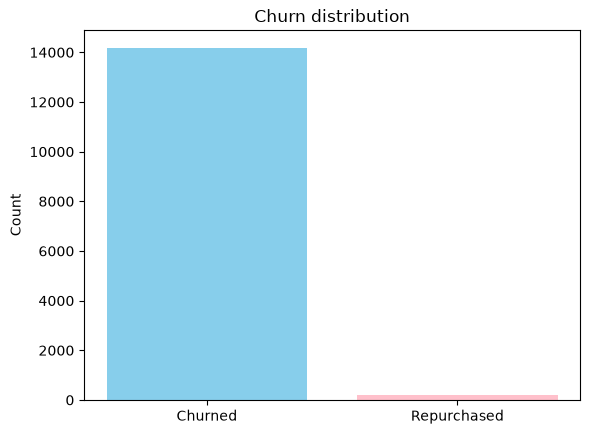

In [80]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

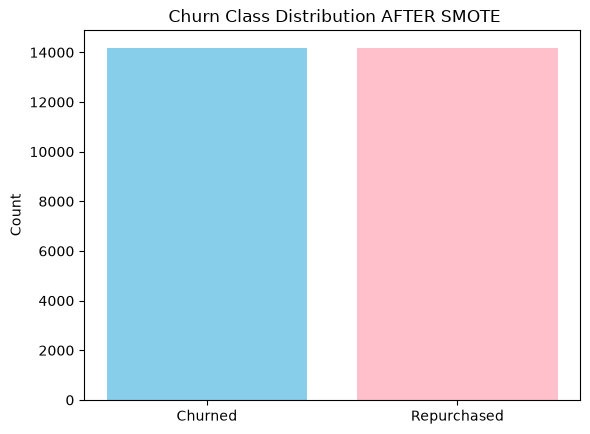

In [81]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

------------------------------------
DT - gini
------------------------------------


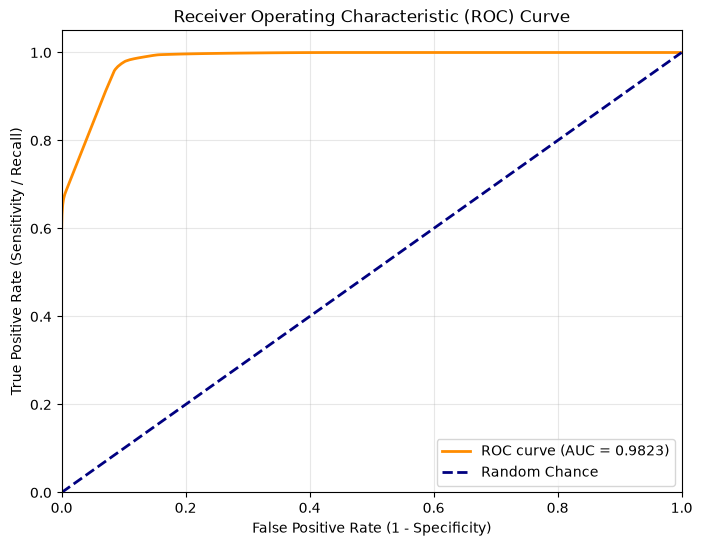

-----  Trainsm  -----
Model F1 score: 0.9411
Model accuracy: 0.9386
[[12716  1461]
 [  279 13898]]



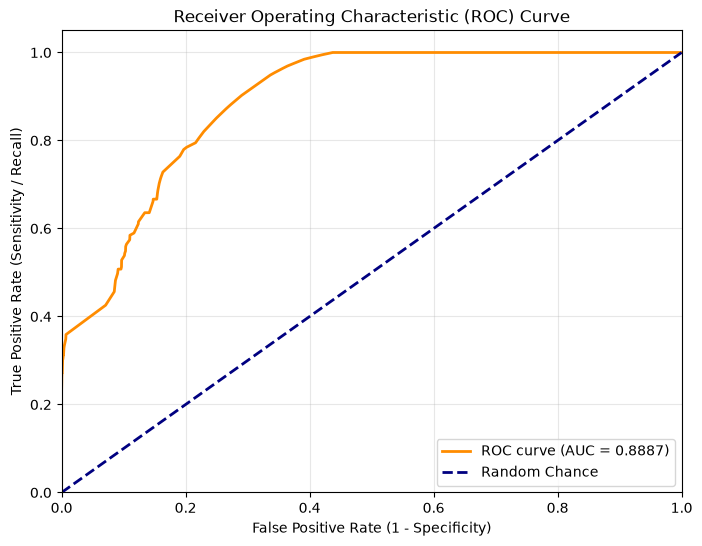

-----  Train  -----
Model F1 score: 0.1214
Model accuracy: 0.8922
[[12716  1461]
 [   88   107]]



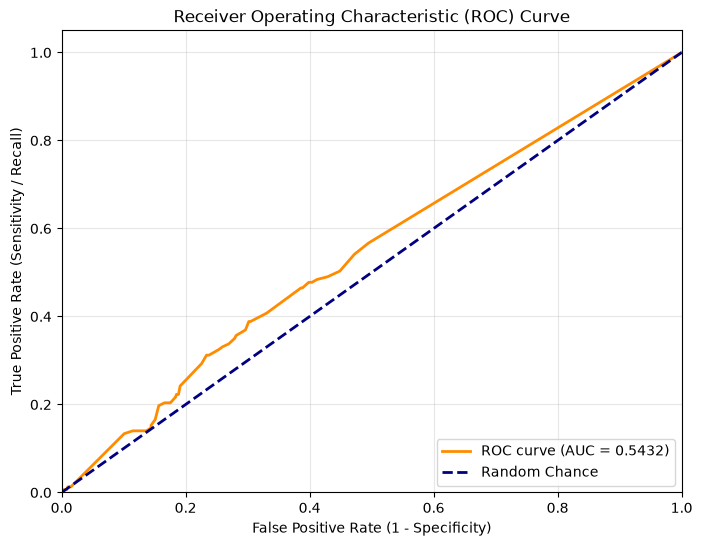

-----  Val  -----
Model F1 score: 0.0185
Model accuracy: 0.8576
[[14007  2195]
 [  135    22]]



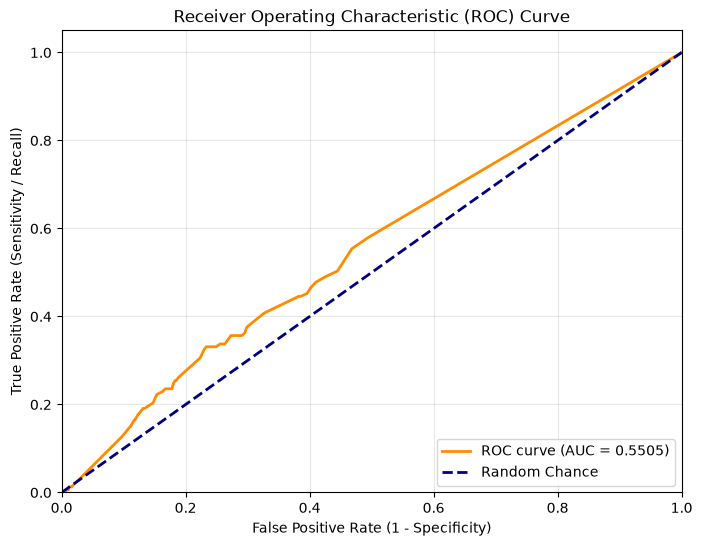

-----  Test  -----
Model F1 score: 0.0256
Model accuracy: 0.8606
[[14050  2153]
 [  127    30]]

------------------------------------


------------------------------------
DT - entropy
------------------------------------


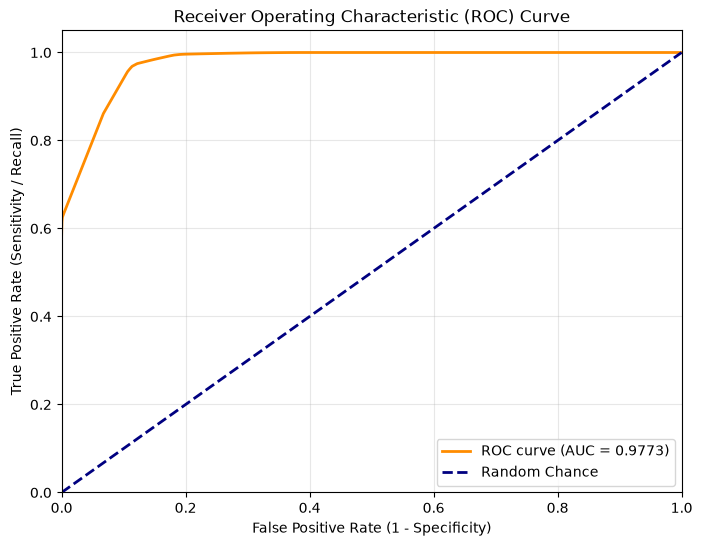

-----  Trainsm  -----
Model F1 score: 0.9298
Model accuracy: 0.9264
[[12450  1727]
 [  360 13817]]



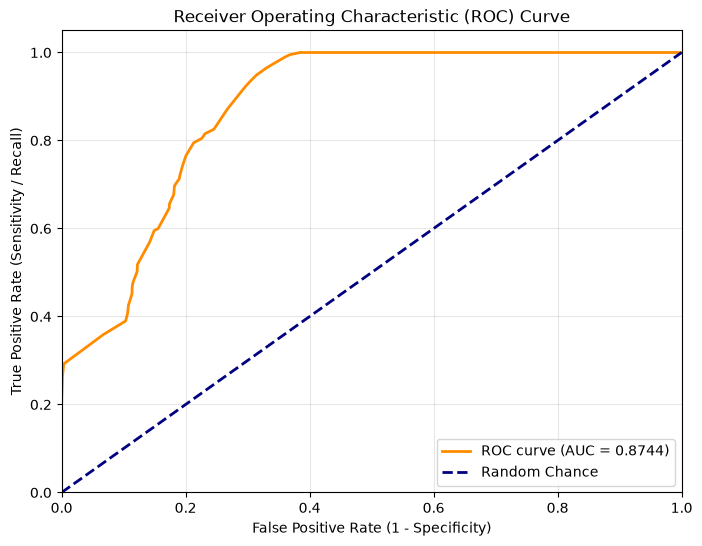

-----  Train  -----
Model F1 score: 0.0970
Model accuracy: 0.8731
[[12450  1727]
 [   97    98]]



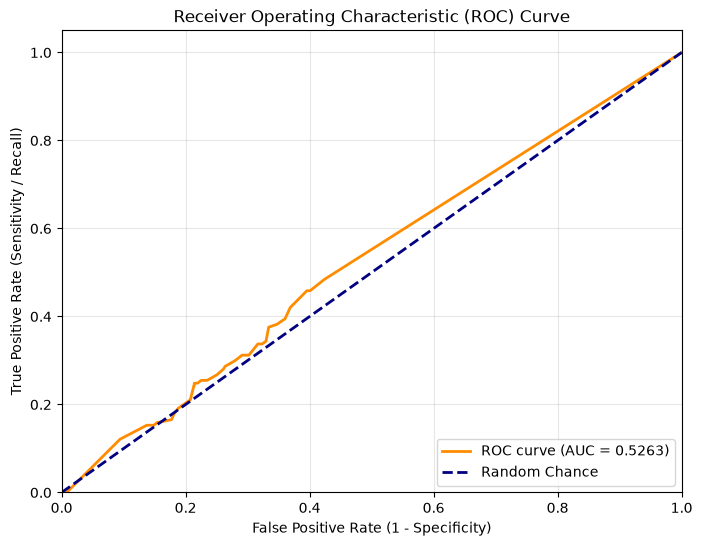

-----  Val  -----
Model F1 score: 0.0185
Model accuracy: 0.8382
[[13687  2515]
 [  132    25]]



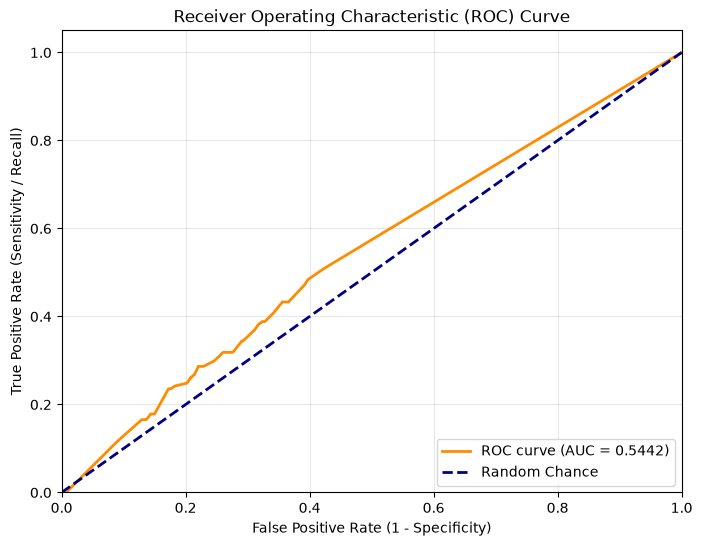

-----  Test  -----
Model F1 score: 0.0215
Model accuracy: 0.8443
[[13784  2419]
 [  129    28]]

------------------------------------


------------------------------------
RF - gini_50
------------------------------------


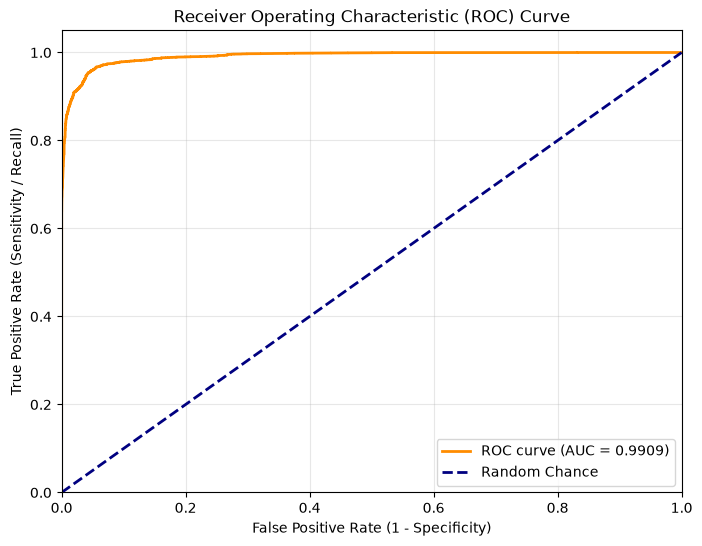

-----  Trainsm  -----
Model F1 score: 0.9422
Model accuracy: 0.9399
[[12769  1408]
 [  296 13881]]



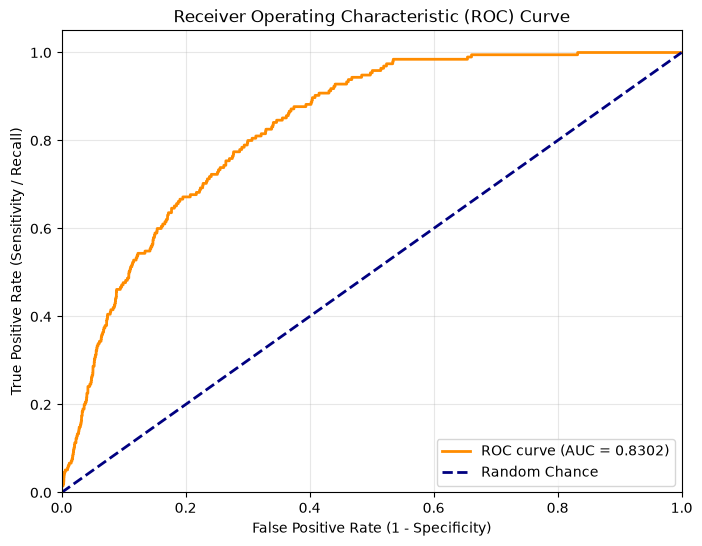

-----  Train  -----
Model F1 score: 0.1097
Model accuracy: 0.8949
[[12769  1408]
 [  102    93]]



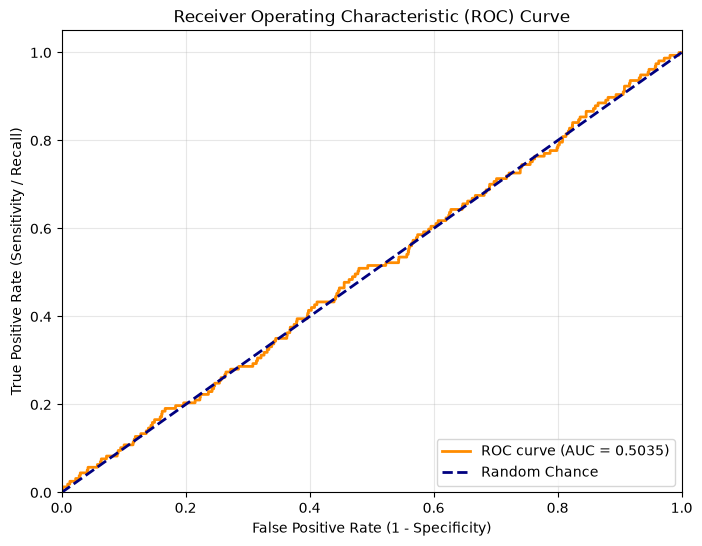

-----  Val  -----
Model F1 score: 0.0186
Model accuracy: 0.8648
[[14126  2076]
 [  136    21]]



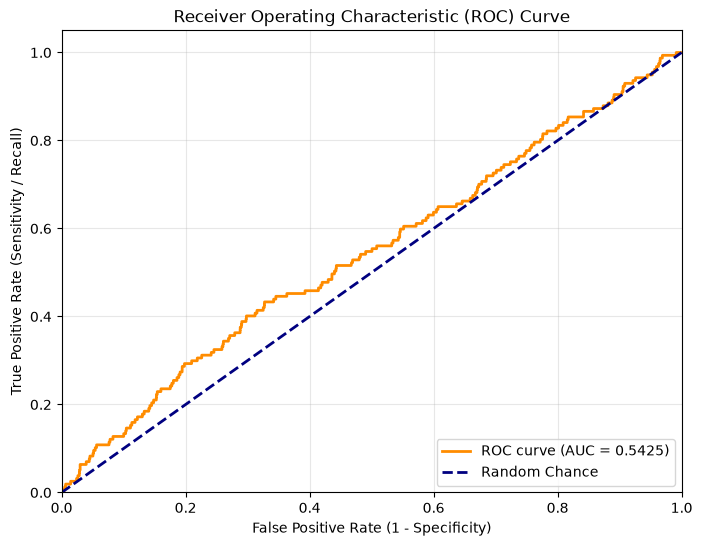

-----  Test  -----
Model F1 score: 0.0244
Model accuracy: 0.8680
[[14173  2030]
 [  130    27]]

------------------------------------


------------------------------------
RF - gini_100
------------------------------------


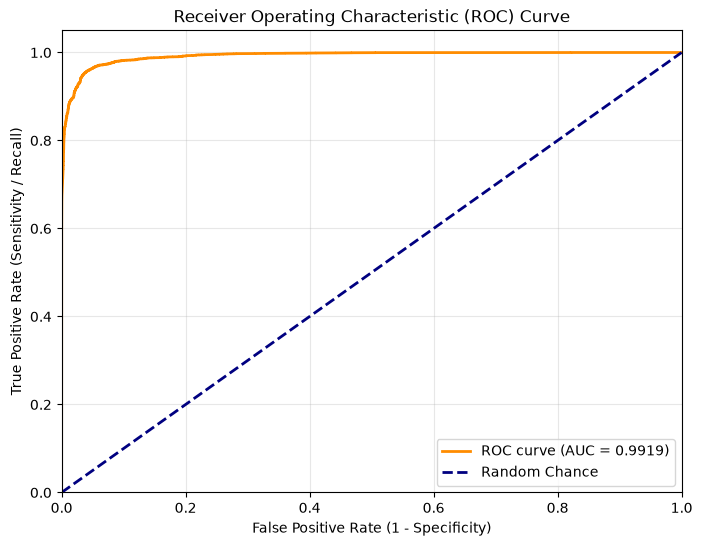

-----  Trainsm  -----
Model F1 score: 0.9424
Model accuracy: 0.9400
[[12730  1447]
 [  254 13923]]



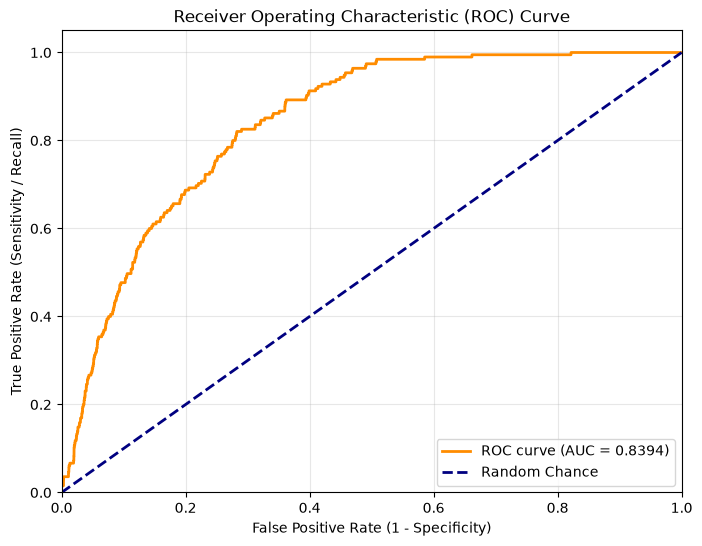

-----  Train  -----
Model F1 score: 0.1072
Model accuracy: 0.8922
[[12730  1447]
 [  102    93]]



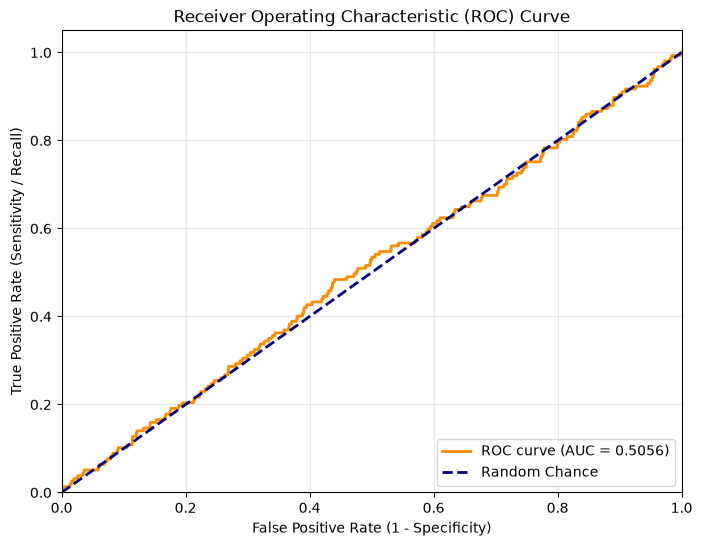

-----  Val  -----
Model F1 score: 0.0193
Model accuracy: 0.8571
[[13998  2204]
 [  134    23]]



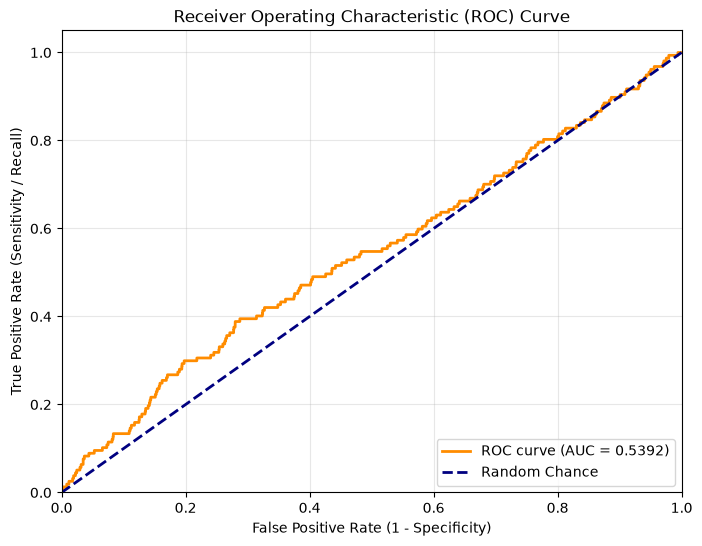

-----  Test  -----
Model F1 score: 0.0244
Model accuracy: 0.8584
[[14015  2188]
 [  128    29]]

------------------------------------


------------------------------------
RF - gini_150
------------------------------------


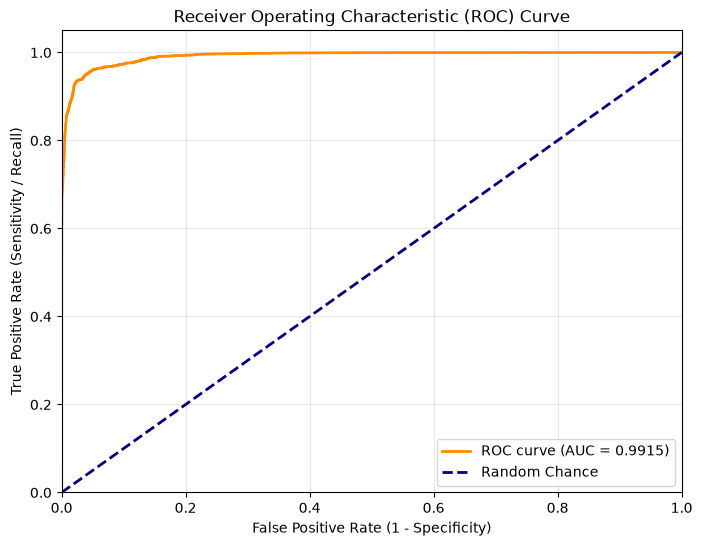

-----  Trainsm  -----
Model F1 score: 0.9345
Model accuracy: 0.9316
[[12571  1606]
 [  334 13843]]



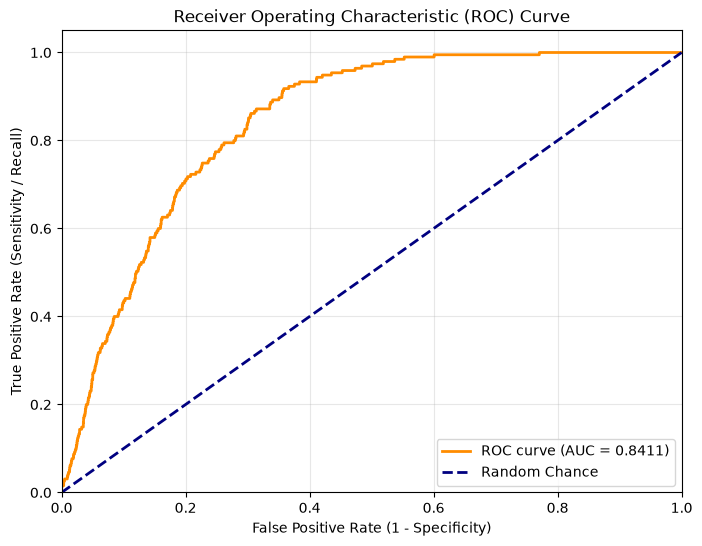

-----  Train  -----
Model F1 score: 0.0952
Model accuracy: 0.8809
[[12571  1606]
 [  105    90]]



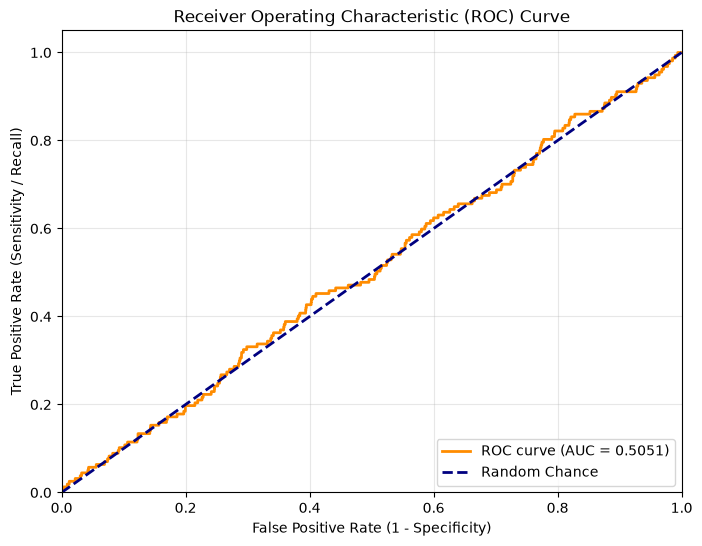

-----  Val  -----
Model F1 score: 0.0186
Model accuracy: 0.8450
[[13799  2403]
 [  133    24]]



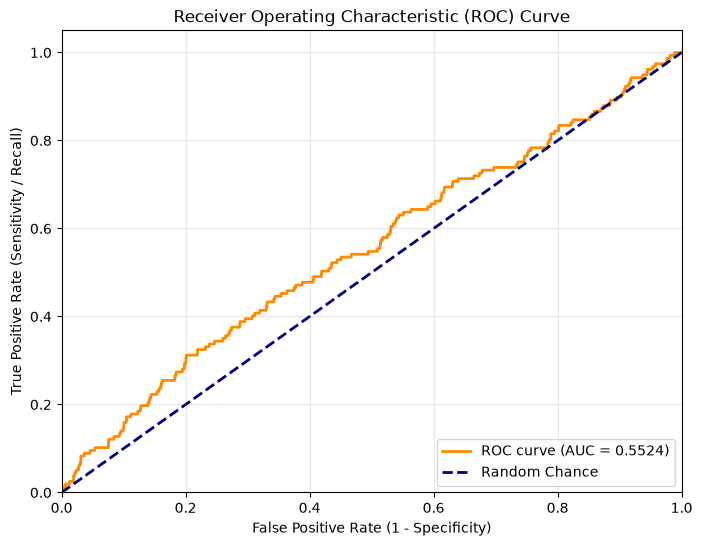

-----  Test  -----
Model F1 score: 0.0274
Model accuracy: 0.8481
[[13840  2363]
 [  122    35]]

------------------------------------




c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
Background dataset has 28354 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=28354 when initializing the masker.


------------------------------------
LogReg
------------------------------------


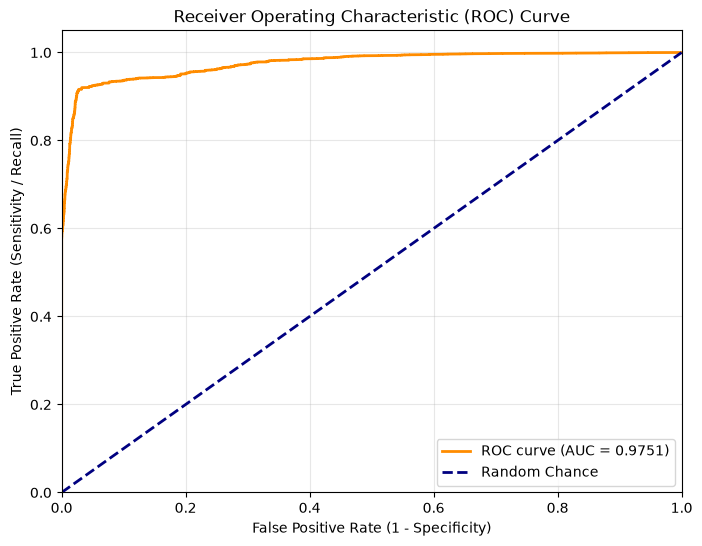

-----  Trainsm  -----
Model F1 score: 0.9408
Model accuracy: 0.9423
[[13728   449]
 [ 1186 12991]]



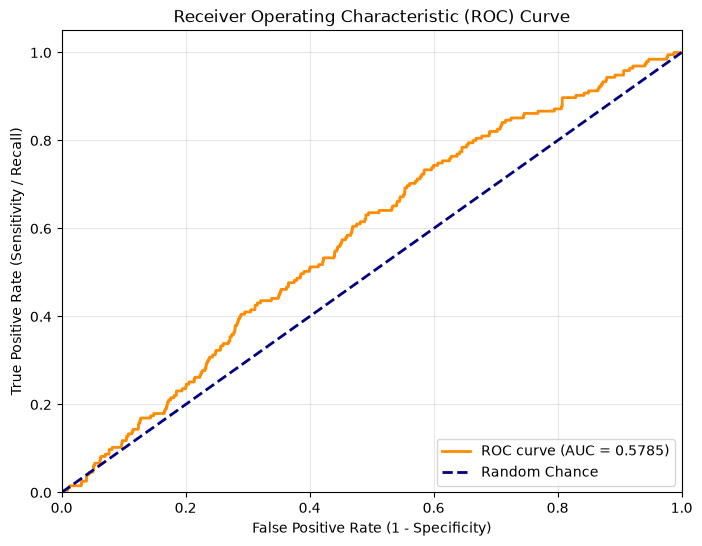

-----  Train  -----
Model F1 score: 0.0093
Model accuracy: 0.9554
[[13728   449]
 [  192     3]]



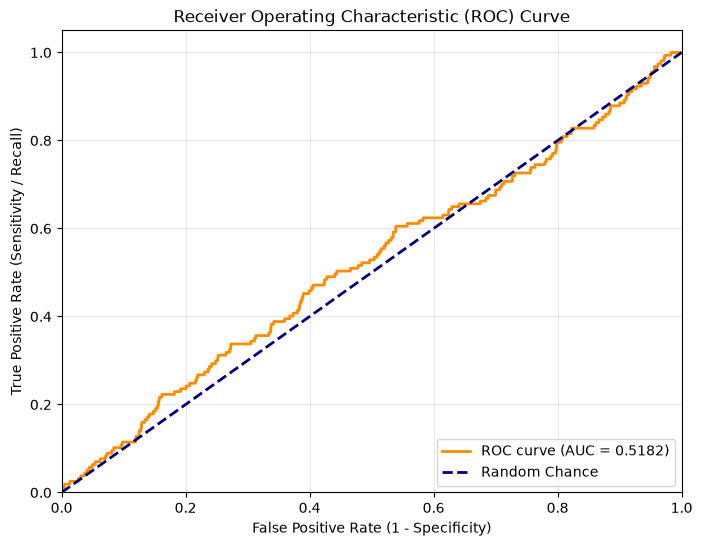

-----  Val  -----
Model F1 score: 0.0189
Model accuracy: 0.9492
[[15520   682]
 [  149     8]]



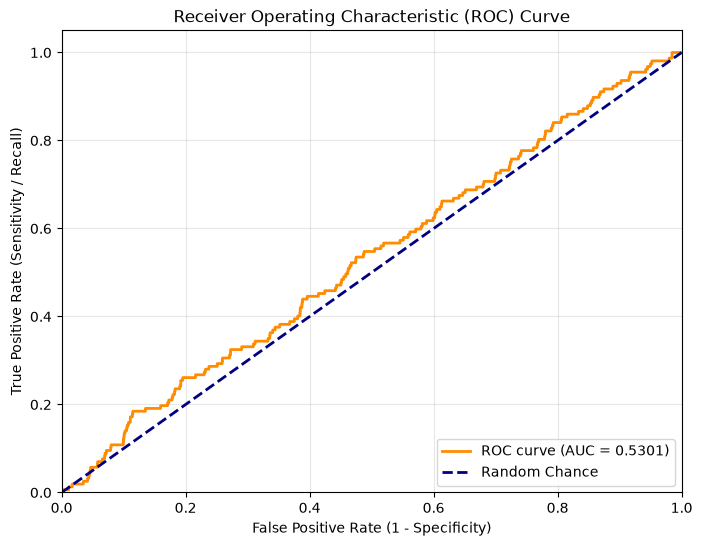

-----  Test  -----
Model F1 score: 0.0119
Model accuracy: 0.9491
[[15522   681]
 [  152     5]]

------------------------------------


------------------------------------
XGBoost - 100
------------------------------------


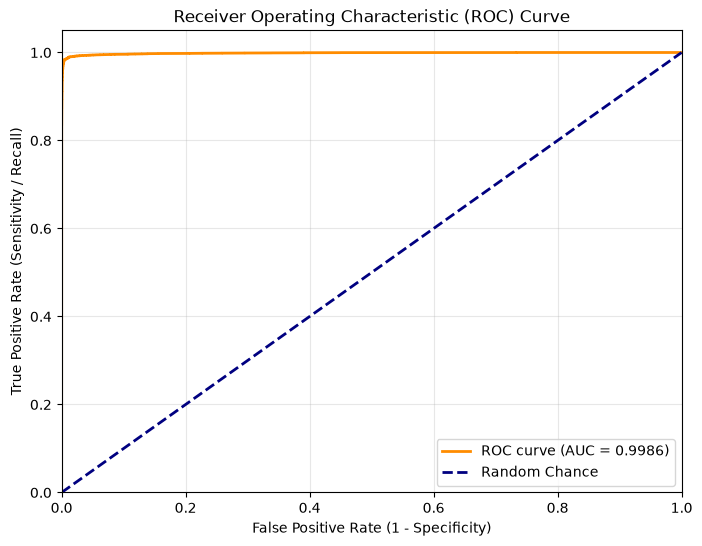

-----  Trainsm  -----
Model F1 score: 0.9884
Model accuracy: 0.9884
[[13991   186]
 [  143 14034]]



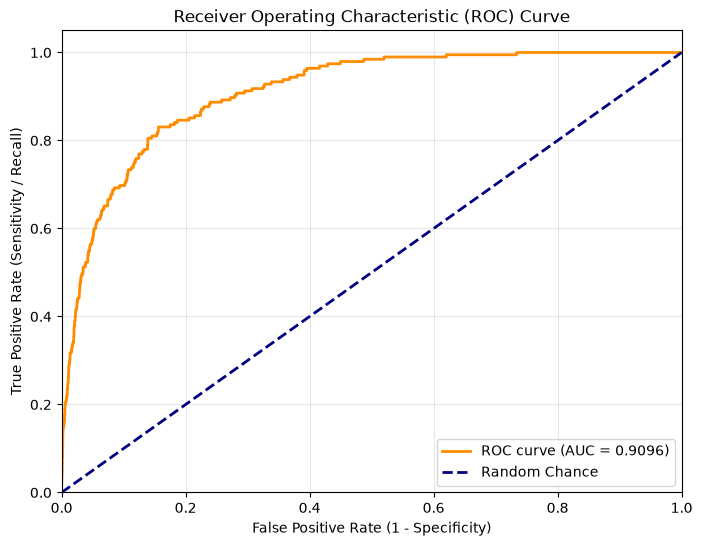

-----  Train  -----
Model F1 score: 0.2642
Model accuracy: 0.9775
[[13991   186]
 [  137    58]]



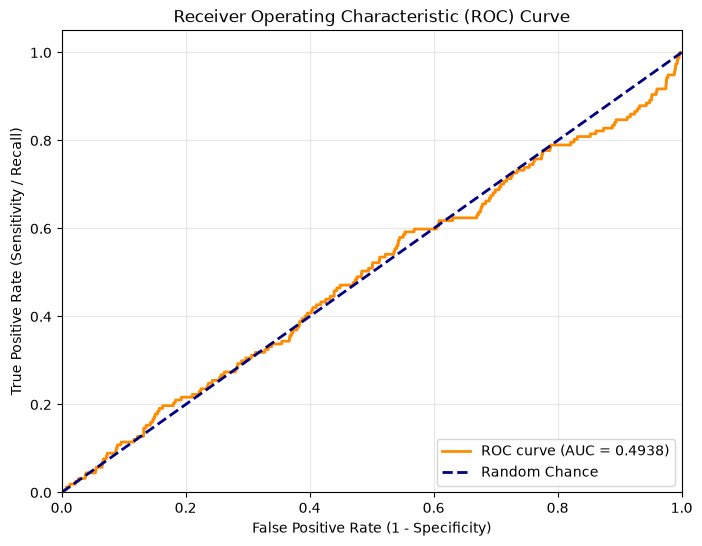

-----  Val  -----
Model F1 score: 0.0145
Model accuracy: 0.9586
[[15676   526]
 [  152     5]]



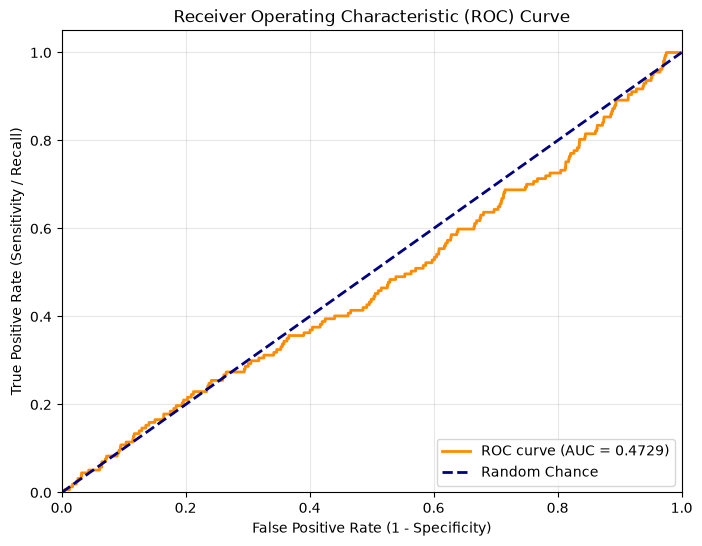

-----  Test  -----
Model F1 score: 0.0149
Model accuracy: 0.9595
[[15692   511]
 [  152     5]]

------------------------------------




In [82]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)
    model_body = clf.steps[-1][1] if hasattr(clf, 'steps') else clf
    if "LogisticRegression" in str(type(model_body)):
        
        explainer = shap.LinearExplainer(model_body, X_train_sm)
        shap_values = explainer(X_test)
    else:
        explainer = shap.TreeExplainer(model_body)
        shap_values = explainer(X_test)
    

    exp_res = {
        "name": name,
        "clf": clf,
        "explainer": explainer,
        "shap_values": shap_values
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 1]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 1, 0)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [93]:
res_df_all = pd.DataFrame.from_records(results)


columns_to_show = [col for col in res_df_all.columns if col not in ["explainer", "shap_values"]]
res_df = res_df_all[columns_to_show]

res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df.to_excel("150_days_rf_lr_dt_xgboost.xlsx")
res_df

,name,clf,Trainsm_f1sore,Trainsm_acc,Trainsm_auc,Trainsm_tn,Trainsm_fp,Trainsm_fn,Trainsm_tp,Train_f1sore,...,Val_fp,Val_fn,Val_tp,Test_f1sore,Test_acc,Test_auc,Test_tn,Test_fp,Test_fn,Test_tp
4,RF - gini_150,"(DecisionTreeClassifier(criterion='entropy', m...",0.934517,0.931579,0.991501,12571,1606,334,13843,0.095188,...,2403,133,24,0.027397,0.848105,0.552354,13840,2363,122,35
0,DT - gini,"DecisionTreeClassifier(max_depth=10, random_st...",0.941089,0.938633,0.982274,12716,1461,279,13898,0.121384,...,2195,135,22,0.025641,0.860636,0.550542,14050,2153,127,30
3,RF - gini_100,"(DecisionTreeClassifier(max_depth=10, max_feat...",0.942431,0.940008,0.991896,12730,1447,254,13923,0.107205,...,2204,134,23,0.024431,0.858435,0.539161,14015,2188,128,29
2,RF - gini_50,"(DecisionTreeClassifier(max_depth=10, max_feat...",0.942171,0.939903,0.990897,12769,1408,296,13881,0.109670,...,2076,136,21,0.024390,0.867971,0.542495,14173,2030,130,27
1,DT - entropy,"DecisionTreeClassifier(criterion='entropy', ma...",0.929780,0.926395,0.977258,12450,1727,360,13817,0.097030,...,2515,132,25,0.021505,0.844254,0.544219,13784,2419,129,28
6,XGBoost - 100,"XGBClassifier(alpha=10, base_score=None, boost...",0.988414,0.988397,0.998555,13991,186,143,14034,0.264237,...,526,152,5,0.014859,0.959474,0.472897,15692,511,152,5
5,LogReg,"(RobustScaler(), LogisticRegression(penalty='l...",0.940797,0.942336,0.975058,13728,449,1186,12991,0.009274,...,682,149,8,0.011862,0.949083,0.530093,15522,681,152,5


In [94]:


# L1 logistic regression and standarzation
X_scaled = StandardScaler().fit_transform(X_train_sm)
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42).fit(X_scaled, y_train_sm)

# generate odds ratio
df_res = pd.DataFrame({'Feature': X_train_sm.columns, 'Beta': model.coef_[0], 'Odds_Ratio': np.exp(model.coef_[0])})
df_res = df_res.iloc[df_res['Beta'].abs().argsort()[::-1]].round(4).reset_index(drop=True)


df_res.to_excel("150_days_odds_beta.xlsx")

c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [95]:
df_res

,Feature,Beta,Odds_Ratio
0,state_income_level_high,-4.1421,0.0159
1,state_income_level_low,-3.7404,0.0237
2,state_income_level_mid,-2.4567,0.0857
3,cat__product_cat_entertainment,-1.7254,0.1781
4,cat__product_cat_household,-1.6687,0.1885
5,cat__product_cat_beauty,-1.3855,0.2502
6,cat__product_cat_electronics,-1.3836,0.2507
7,cat__product_cat_miscellaneous,-1.0234,0.3594
8,cat__product_cat_office,-0.9653,0.3809
9,cat__product_cat_sports_leisure,-0.8147,0.4428


=== Displaying SHAP Summary Plot for Best Model: RF - gini_150 ===


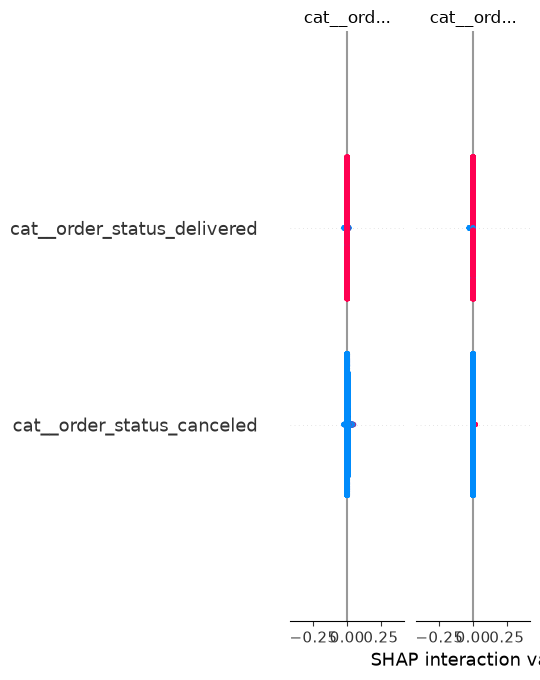

In [96]:
import shap

best_model_name = res_df.iloc[0]["name"]


target_res = next(item for item in results if item["name"] == best_model_name)

print(f"=== Displaying SHAP Summary Plot for Best Model: {target_res['name']} ===")

# SHAP値の可視化
if target_res["shap_values"] is not None:
    
    
    shap.summary_plot(target_res["shap_values"], X_test)
else:
    print("This model does not have SHAP values calculated.")

------
------